# Análise RFM — Segmentação de Clientes

*Notebook consolidado a partir de todo o material desenvolvido ao longo da conversa:
três pipelines de código distintos, dois slides conceituais e as correções discutidas
em cada etapa.*

---

## 1. Objetivo da análise

**Problema de negócio.** Uma base de transações de varejo registra o que cada cliente
comprou, quando e por quanto — mas não diz *quais clientes merecem qual tratamento*.
Sem essa distinção, ações de marketing tratam igualmente quem comprou ontem e quem
sumiu há um ano, quem gasta muito e quem gasta pouco. O custo disso é duplo: desperdício
de verba em quem já ia comprar e perda silenciosa de clientes valiosos que estavam
saindo sem ninguém perceber.

**Objetivo analítico.** Transformar o histórico transacional em uma segmentação de
clientes baseada em três dimensões de comportamento de compra — **Recência**,
**Frequência** e **Valor Monetário** (RFM) — de modo que cada cliente receba um rótulo
acionável, e que cada rótulo tenha uma regra explícita e auditável por trás.

**Por que RFM e não outra técnica.** RFM é deliberadamente simples: usa apenas dados
que qualquer sistema transacional já tem, não exige rótulo histórico (é não
supervisionado por construção) e produz segmentos que a área de negócio entende sem
precisar confiar num modelo caixa-preta. Essa interpretabilidade é o principal
argumento a favor dele — e também define seu limite, discutido na seção 15.

**Entregáveis desta análise:**

1. Tabela RFM por cliente (Recency, Frequency, Monetary).
2. Scores de 1 a 5 em cada dimensão, com método de discretização justificado.
3. Segmentos nomeados, com a regra de atribuição explícita.
4. Perfil quantitativo de cada segmento (tamanho, receita, ticket, recência).
5. Insights calculados a partir dos dados, separando fato de interpretação.

## 2. Dados

### 2.1 Granularidade e colunas necessárias

A análise parte de dados **no nível de item de transação**: uma linha por produto
vendido dentro de um pedido. Essa é a granularidade mais fina disponível e a única que
permite reconstruir todas as métricas sem depender de agregações prontas.

| Coluna | Tipo | Papel na análise |
|---|---|---|
| `Customer ID` | numérico/string | Chave de agregação — define "cliente" |
| `Invoice` | string/numérico | Identificador do pedido — base da **Frequência** |
| `InvoiceDate` | datetime | Data da transação — base da **Recência** |
| `Quantity` | inteiro | Quantidade comprada (negativa = devolução) |
| `Price` | float | Preço unitário |

`Quantity × Price` gera o valor da linha, cuja soma por cliente é o **Monetário**.

### 2.2 Decisões de consolidação

Ao longo da conversa foram enviados **três pipelines diferentes** para o mesmo problema,
com esquemas de coluna incompatíveis entre si. Esta seção documenta o que foi escolhido
de cada um e por quê — nenhum código foi descartado sem justificativa.

| Origem | Esquema / trecho enviado | Decisão | Justificativa |
|---|---|---|---|
| **Pipeline 1** | `df_dataset`: `_CustomerID`, `OrderDate`, `OrderNumber`, `Revenue`; scores via `qcut` com `labels=range(5,0,-1)` | **Escala 1–5 adotada**; `qcut` mantido como método primário | Quintis são a convenção em RFM e dão mais resolução em Recência e Monetário, que são contínuos |
| **Pipeline 1** | `rfm_dataset.assign(...)` sem capturar o retorno | **Corrigido** | `.assign()` não é in-place; sem `rfm = ...` o resultado era descartado |
| **Pipeline 2** | `cleaned_df` / `aggregated_df`: `Customer ID`, `Invoice`, `InvoiceDate`, `Quantity`, `Price`; `SalesLineTotal = Quantity * Price` | **Esquema canônico desta análise** | É o único nível de granularidade que permite fazer Data Quality de verdade (devoluções, preços inválidos) em vez de receber valores já somados |
| **Pipeline 2** | `Frequency=("Invoice","nunique")` | **Adotado** | Corrige o `'count'` usado nos Pipelines 1 e 3, que contava *itens* em vez de *pedidos* |
| **Pipeline 2** | Remoção de outliers por IQR + `StandardScaler` + `KMeans` | **IQR mantido como diagnóstico, remoção descartada**; KMeans documentado na seção 15 | Detalhado em 2.3 — remover outliers antes de um score por quantil apagaria justamente os melhores clientes |
| **Pipeline 3** | `data`: `CustomerID`, `InvoiceDate`, `InvoiceNo`, `TotalAmount` | **`TotalAmount` passa a ser derivado**, não recebido pronto | Mantém a rastreabilidade de como o valor foi calculado |
| **Pipeline 3** | `reference_date = data['InvoiceDate'].max() + timedelta(days=1)` | **Adotado** | Substitui a primeira versão com `dt.now()`, que tornava a recência dependente do dia em que o notebook roda |
| **Pipeline 3** | Função `RScore` com quantis manuais, escala 1–4 | **Lógica de inversão da Recência adotada; escala trocada para 1–5 e implementação vetorizada** | A inversão estava correta; o `.apply()` linha a linha é lento e silencioso sobre empates (ver seção 10) |
| **Pipeline 3** | `assign_segment` (`<5` Low, `<9` Mid, else High) sobre score 3–12 | **Cortes recalculados a partir da distribuição observada** | Na escala 1–5 o score vai de 3 a 15; reaproveitar os cortes 5/9 daria grupos desbalanceados. Além disso, na escala original "Low-Value" cobria só os scores 3 e 4 |
| **Pipeline 3** | `RFM_Customer_Segments` por faixas de soma (VIP/Loyal, Potential Loyal, At Risk, Can't Lose, Lost) | **Nomes mantidos; regra trocada de soma para padrão R/F/M** | Detalhado em 2.4 — a soma não distingue perfis opostos |
| **Pipeline 3** | `segment == 'Champions'` no destaque de cor | **Corrigido** | Nenhum segmento se chamava "Champions" no código; a condição nunca era verdadeira e o destaque nunca aparecia |
| **Slides** | Definição de R/F/M e 5 segmentos nomeados com % e $ ilustrativos | **Nomes usados como referência conceitual; números descartados** | Os percentuais do slide eram exemplo didático, não resultado desta base |

### 2.3 Por que os outliers **não** são removidos aqui

O Pipeline 2 removia outliers de `MonetaryValue` e `Frequency` por IQR antes de
padronizar e rodar KMeans. Naquele contexto a remoção era correta: KMeans agrupa por
distância euclidiana e é fortemente sensível a pontos extremos.

Para um score por **quantil**, a conclusão se inverte. Quantis são estatísticas de
posição — são robustos a outliers por construção. Pior: em RFM, o cliente de gasto
extremo normalmente **é** o cliente que a análise existe para encontrar. Removê-lo antes
de pontuar significa jogar fora os "Champions" e depois procurar por eles.

**Decisão:** o diagnóstico de IQR é calculado e reportado (é informação útil sobre a
cauda da distribuição), mas nenhum cliente é removido por ser outlier. A remoção só
voltaria a ser necessária se a análise seguisse para o caminho de clustering.

### 2.4 Por que a segmentação **não** usa a soma R+F+M

A soma `R + F + M` colapsa três dimensões em um número e, com isso, torna perfis opostos
indistinguíveis. Na escala 1–5, um cliente `R=5, F=1, M=1` (comprou ontem, primeira
compra) e um cliente `R=1, F=3, M=3` (era regular, sumiu) somam **7** os dois. São
situações de negócio antagônicas: o primeiro precisa de onboarding, o segundo de
reativação urgente.

O segmento "At Risk Customers" é literalmente invisível para uma regra baseada em soma,
porque sua definição é *recência baixa com frequência/valor altos* — uma combinação, não
um total. **Decisão:** a segmentação principal usa regras sobre o padrão R/F/M; a soma é
mantida como score secundário de priorização e comparada à segmentação por padrão na
seção 11.

### 2.5 Limitações dos dados

- **Sem dados demográficos ou de canal** — a segmentação descreve comportamento de
  compra, não perfil de pessoa.
- **Sem custo por produto** — "valor" aqui é receita bruta, não margem. Um cliente de
  alta receita e baixa margem aparece como valioso.
- **Janela de observação finita** — clientes que compraram antes do início da base
  parecem novos; clientes do fim da janela têm frequência subestimada.
- **Cliente não identificado** — transações sem `Customer ID` não podem entrar na
  análise (tratadas na seção 5).

## 3. Importação das bibliotecas

Cada biblioteca entra por um motivo específico, não por hábito:

- **pandas** — toda a manipulação tabular: agregação por cliente, discretização
  (`qcut`/`cut`), tabelas de perfil.
- **numpy** — geração reprodutível de dados, operações vetorizadas e `np.inf` nos
  cortes fixos.
- **matplotlib** e **seaborn** — gráficos estáticos de diagnóstico (histogramas e
  boxplots da seção 9). São a ferramenta certa para análise exploratória rápida.
- **plotly.express** e **plotly.graph_objects** — gráficos da seção 13, destinados a
  leitura interativa (hover com valores exatos, treemap navegável). `express` para
  gráficos diretos, `graph_objects` quando é preciso controlar cada série
  individualmente.

In [2]:
%matplotlib inline

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
sns.set_theme(style='whitegrid')

# Parâmetros da análise, centralizados para que nenhuma etapa tenha número mágico solto.
# ASSUMPTION: escala de 5 pontos (quintis). O material enviado tinha duas escalas — 1-5
# no Pipeline 1 (qcut com 5 bins) e 1-4 no Pipeline 3 (função RScore). Adotamos 5 por ser
# a convenção em RFM e por dar mais resolução nas variáveis contínuas. Todo o restante do
# notebook deriva desta constante, então trocar para 4 exige alterar só esta linha.
N_SCORES = 5

# ASSUMPTION: cortes fixos de Frequência usados como plano B quando os quantis colapsam
# por empate (ver seção 10). Os limites representam níveis de recompra com significado
# de negócio: 1 compra, 2, 3, 4-5, 6 ou mais.
CORTES_FREQUENCIA = [0, 1, 2, 3, 5, np.inf]

SEED = 42

**Explicação do bloco**

- `%matplotlib inline` — magic do Jupyter que fixa o backend de renderização dentro do
  notebook. Sem ela, em alguns ambientes as figuras abrem em janela separada ou não
  aparecem.
- `pd.set_option('display.float_format', ...)` — recebe uma função aplicada a todo float
  exibido. A lambda formata com separador de milhar e 2 casas (`f'{v:,.2f}'`). Isso
  importa numa análise monetária: sem ela, valores grandes saem em notação científica e
  ficam ilegíveis nas tabelas de perfil.
- `sns.set_theme(style='whitegrid')` — aplica o tema do seaborn globalmente, inclusive
  nos gráficos feitos direto em matplotlib. A grade clara ajuda a ler magnitude em
  histogramas.
- `N_SCORES = 5` — a decisão de escala vira uma constante em vez de ficar repetida em
  cada chamada de `qcut`. É o que permite que os cortes de segmento da seção 11 sejam
  *derivados* da escala, e não números fixos herdados de outra escala (foi exatamente
  esse descasamento que apareceu no material original, onde cortes calibrados para a
  faixa 3–12 apareciam junto de scores 1–5).
- `CORTES_FREQUENCIA` — lista de 6 limites, que define 5 faixas, coerente com
  `N_SCORES=5`. `np.inf` como último limite garante que nenhum cliente de altíssima
  frequência fique fora do corte.
- `SEED` — fixa a aleatoriedade da base sintética, tornando o notebook reproduzível.

## 4. Carregamento dos dados

> **ASSUMPTION — base sintética.** A base real não foi disponibilizada nesta conversa;
> os trechos enviados mostravam apenas o código, não o arquivo. Para que o notebook seja
> executável e verificável de ponta a ponta, esta seção **gera** uma base sintética com
> o mesmo esquema e — importante — com os mesmos *defeitos* que foram discutidos ao
> longo do desenvolvimento: clientes sem identificação, devoluções com quantidade
> negativa, preços zerados, linhas duplicadas e uma forte concentração de clientes com
> uma única compra.
>
> Essa escolha é deliberada: uma base sintética "limpa" faria a seção de Data Quality
> passar sem encontrar nada e a seção de scores nunca exercitar o caminho de empate.
>
> **Para usar com dados reais, substitua o corpo desta célula por
> `raw_df = pd.read_csv('sua_base.csv', parse_dates=['InvoiceDate'])`** e siga direto
> para a seção 5. Nenhuma outra célula precisa mudar.
>
> Nenhum número apresentado neste notebook deve ser lido como resultado da base real do
> negócio — os valores que aparecerem ao executar vêm da base sintética.

In [19]:
def gerar_base_sintetica(n_clientes=1200, seed=SEED):
    """Gera transações item a item com os problemas de qualidade tratados na seção 5.

    A estrutura imita varejo: a maior parte dos clientes compra uma única vez, uma
    minoria compra muitas vezes, e o valor por item é assimétrico à direita.
    """
    rng = np.random.default_rng(seed)
    fim_janela = pd.Timestamp('2011-12-09')
    linhas = []
    invoice = 500000

    for cliente in range(1, n_clientes + 1):
        # Recencia sorteada por cliente e espalhada por toda a janela: e o que faz
        # Recency ser uma variavel continua e bem distribuida.
        dias_desde_ultima = int(rng.integers(0, 730))
        # Mistura deliberada: 55% compram uma vez só. É essa massa em Frequency=1 que
        # faz os quantis colapsarem e exige o tratamento de empate da seção 10.
        n_pedidos = 1 if rng.random() < 0.55 else int(rng.integers(2, 15))
        intervalo = int(rng.integers(10, 120))   # ciclo de recompra do cliente

        for p in range(n_pedidos):
            # p=0 e a ultima compra; os anteriores recuam no tempo pelo ciclo do cliente
            offset = dias_desde_ultima + p * intervalo
            if offset > 729:
                break   # pedido anterior ao inicio da janela: nao foi observado
            invoice += 1
            data = fim_janela - pd.Timedelta(days=offset) + pd.Timedelta(hours=int(rng.integers(8, 19)))
            devolucao = rng.random() < 0.04

            for _ in range(int(rng.integers(1, 6))):
                qtd = -int(rng.integers(1, 5)) if devolucao else int(rng.integers(1, 15))
                preco = round(float(rng.lognormal(mean=2.0, sigma=0.9)), 2)
                linhas.append((cliente, str(invoice), data, qtd, preco))

    df = pd.DataFrame(linhas, columns=['Customer ID', 'Invoice', 'InvoiceDate', 'Quantity', 'Price'])

    # Defeitos injetados de propósito, cada um exercitando uma checagem da seção 5.
    df.loc[df.sample(frac=0.018, random_state=1).index, 'Customer ID'] = np.nan
    df.loc[df.sample(frac=0.006, random_state=2).index, 'Price'] = 0.0
    duplicatas = df.sample(frac=0.01, random_state=3)
    df = pd.concat([df, duplicatas], ignore_index=True)

    return df.sample(frac=1, random_state=4).reset_index(drop=True)


raw_df = gerar_base_sintetica()
raw_df['InvoiceDate'] = pd.to_datetime(raw_df['InvoiceDate'])

print(f'Linhas: {len(raw_df):,}')
print(f'Clientes identificados: {raw_df["Customer ID"].nunique():,}')
print(f'Período: {raw_df["InvoiceDate"].min():%d/%m/%Y} a {raw_df["InvoiceDate"].max():%d/%m/%Y}')
raw_df.head(7)

Linhas: 10,293
Clientes identificados: 1,197
Período: 10/12/2009 a 09/12/2011


,Customer ID,Invoice,InvoiceDate,Quantity,Price
0,675.00,501957,2011-10-09 12:00:00,14,13.22
1,"1,101.00",503154,2009-12-20 16:00:00,-4,7.91
2,794.00,502288,2010-08-02 10:00:00,8,5.79
3,555.00,501585,2010-10-03 12:00:00,7,15.16
4,620.00,501819,2011-11-05 16:00:00,11,1.85
5,353.00,500990,2010-01-13 13:00:00,13,22.30
6,"1,015.00",502880,2010-04-14 10:00:00,8,7.06


**Explicação do bloco**

- `np.random.default_rng(seed)` — gerador moderno do numpy (preferível ao antigo
  `np.random.seed`, que é global e afeta outras bibliotecas). Receber `seed` garante que
  duas execuções produzam exatamente a mesma base.
- `n_pedidos = 1 if rng.random() < 0.55 else int(rng.integers(2, 15))` — é a linha que
  define o formato da distribuição de Frequência. O sorteio joga 55% dos clientes em
  exatamente 1 pedido. Isso não é um detalhe cosmético: é a condição que faz os quintis
  de Frequência terem bordas repetidas, cenário em que `pd.qcut` falha com
  `Bin edges must be unique`. A base precisa ter esse defeito para que o tratamento da
  seção 10 seja de fato testado.
- `dias_desde_ultima = int(rng.integers(0, 730))` — cada cliente sorteia sua **própria**
  distância até a última compra, espalhada por toda a janela. É o que torna a Recência
  uma variável razoavelmente contínua, em que os quantis funcionam sem ressalva —
  contraste deliberado com a Frequência, que exige o caminho alternativo.
- `offset = dias_desde_ultima + p * intervalo` com `break` em `offset > 729` — os pedidos
  são construídos **de trás para frente**, recuando a partir da última compra pelo ciclo
  de recompra do próprio cliente. O `break` descarta pedidos que cairiam antes do início
  da janela de observação, o que reproduz de propósito a truncagem discutida na seção 15:
  o histórico anterior à janela simplesmente não existe na base.
- `qtd = -int(...) if devolucao else int(...)` — devoluções entram como **quantidade
  negativa**. É a convenção mais comum em bases transacionais e é o que produz valor de
  linha negativo, tratado na seção 6.
- `rng.lognormal(mean=2.0, sigma=0.9)` — a lognormal só gera valores positivos e tem
  cauda longa à direita, que é o comportamento real de preço e gasto: muitos itens
  baratos, poucos muito caros. Uma uniforme produziria uma distribuição simétrica que
  tornaria toda a discussão de assimetria da seção 9 artificial.
- As três linhas de "defeitos injetados": `Customer ID` nulo em ~1,8% das linhas, `Price`
  zerado em ~0,6%, e ~1% de linhas duplicadas via `pd.concat`. Cada uma existe para ser
  encontrada pela seção 5 — uma checagem de qualidade que nunca acha nada não prova nada.
- `df.sample(frac=1, ...)` — embaralha as linhas para que a ordem do arquivo não carregue
  informação (evita, por exemplo, que um `rank(method='first')` sobre dados ordenados
  produza um viés sistemático).
- Os `print` usam f-string com `:,` (separador de milhar) e `:%d/%m/%Y` (formatação de
  data direto no f-string), dando um resumo imediato do que foi carregado.

## 5. Data Quality

Esta seção roda **antes** de qualquer cálculo de RFM, e a ordem importa: recência,
frequência e valor são todos somas ou extremos calculados sobre as linhas. Qualquer
defeito aqui se propaga silenciosamente para as três métricas e, de lá, para os
segmentos — sem lançar erro nenhum.

O que é verificado e por quê:

| Checagem | Por que importa para RFM |
|---|---|
| Nulos em `Customer ID` | Sem chave não há cliente; a linha é inatribuível |
| Nulos em `Quantity`/`Price` | `NaN × número = NaN`, e a soma ignora — o Monetário fica subestimado sem aviso |
| Duplicatas exatas | Inflam Monetário e podem inflar Frequência |
| Tipos de dados | `InvoiceDate` como texto quebra a subtração de datas |
| `Quantity <= 0` | Devoluções/cancelamentos — não são compras |
| `Price <= 0` | Brindes, erros de cadastro ou ajustes contábeis |
| Datas fora da janela | Erro de registro; distorce a recência |
| Clientes com saldo negativo | Devolveram mais do que compraram — score monetário não faz sentido |

In [4]:
def diagnosticar_qualidade(df):
    """Relatório de qualidade. Não altera nada — apenas mede e reporta."""
    n = len(df)
    print(f'{"CHECAGEM":<42} {"QTD":>10} {"% DO TOTAL":>12}')
    print('-' * 66)

    def linha(rotulo, mascara):
        qtd = int(mascara.sum())
        print(f'{rotulo:<42} {qtd:>10,} {qtd / n * 100:>11.2f}%')
        return qtd

    linha('Linhas sem Customer ID', df['Customer ID'].isna())
    linha('Linhas com Quantity nula', df['Quantity'].isna())
    linha('Linhas com Price nulo', df['Price'].isna())
    linha('Linhas com InvoiceDate nula', df['InvoiceDate'].isna())
    linha('Linhas duplicadas (todas as colunas)', df.duplicated())
    linha('Quantity <= 0 (devolucao/cancelamento)', df['Quantity'] <= 0)
    linha('Price <= 0 (brinde ou erro de cadastro)', df['Price'] <= 0)

    print('-' * 66)
    print('\nTipos de dados:')
    print(df.dtypes.to_string())

    # Cancelamentos marcados por prefixo no numero da nota sao convencao em varias bases
    # de varejo. A checagem so faz sentido se Invoice for texto, entao e condicional.
    if pd.api.types.is_string_dtype(df['Invoice']) or df['Invoice'].dtype == object:
        prefixo_c = df['Invoice'].astype(str).str.upper().str.startswith('C')
        print(f'\nNotas com prefixo "C" (cancelamento): {int(prefixo_c.sum()):,}')

    print(f'\nJanela de datas: {df["InvoiceDate"].min():%d/%m/%Y} a {df["InvoiceDate"].max():%d/%m/%Y}')
    print(f'Datas no futuro (erro de registro): {int((df["InvoiceDate"] > pd.Timestamp.today()).sum()):,}')


diagnosticar_qualidade(raw_df)

CHECAGEM                                          QTD   % DO TOTAL
------------------------------------------------------------------
Linhas sem Customer ID                            185        1.80%
Linhas com Quantity nula                            0        0.00%
Linhas com Price nulo                               0        0.00%
Linhas com InvoiceDate nula                         0        0.00%
Linhas duplicadas (todas as colunas)              102        0.99%
Quantity <= 0 (devolucao/cancelamento)            355        3.45%
Price <= 0 (brinde ou erro de cadastro)            61        0.59%
------------------------------------------------------------------

Tipos de dados:
Customer ID           float64
Invoice                object
InvoiceDate    datetime64[ns]
Quantity                int64
Price                 float64

Notas com prefixo "C" (cancelamento): 0

Janela de datas: 10/12/2009 a 09/12/2011
Datas no futuro (erro de registro): 0


**Explicação do bloco**

- A função **não modifica o dataframe**. Diagnóstico e tratamento ficam separados de
  propósito: misturar os dois é como se perde o registro do que a base tinha antes da
  limpeza, que é justamente a informação que se quer reportar.
- `linha(rotulo, mascara)` — closure que recebe uma máscara booleana, conta com `.sum()`
  (em booleano, `True` vale 1) e imprime valor absoluto e percentual. Evita repetir sete
  vezes o mesmo bloco de formatação.
- `f'{rotulo:<42} {qtd:>10,} {qtd / n * 100:>11.2f}%'` — os especificadores `<` e `>`
  alinham à esquerda e à direita em largura fixa, montando uma tabela legível no texto
  puro sem precisar de biblioteca.
- `df.duplicated()` — marca `True` da segunda ocorrência em diante de cada linha
  repetida, considerando todas as colunas. Em base transacional a duplicata exata é
  quase sempre erro de carga: duas linhas idênticas de item, mesmo pedido, mesmo
  timestamp, mesmo preço.
- `df['Quantity'] <= 0` — cobre negativos (devolução) e zeros (registro sem efeito) numa
  checagem só.
- `pd.api.types.is_string_dtype(...)` — a verificação de prefixo `'C'` é executada
  **condicionalmente**. Assumir que toda base marca cancelamento assim seria inventar
  uma regra que não foi informada; testar o tipo antes evita tanto o erro quanto a
  suposição indevida.
- `(df["InvoiceDate"] > pd.Timestamp.today()).sum()` — data no futuro é sintoma clássico
  de erro de digitação de ano e distorceria a recência para baixo (o cliente pareceria
  ter comprado recentemente).

## 6. Preparação dos dados

Cada transformação abaixo corresponde a uma decisão analítica explícita:

**1. Remover linhas sem `Customer ID`.** RFM é por cliente; uma transação sem chave não
pode ser atribuída. Excluir é a única opção — imputar um cliente seria inventar dado.

**2. Remover duplicatas exatas.** Inflam receita e podem inflar frequência.

**3. Criar `LineTotal = Quantity × Price`.** É a reconstrução explícita do que o
Pipeline 3 recebia pronto como `TotalAmount`. Fazer o cálculo aqui mantém rastreável de
onde o valor veio.

**4. Tratar devoluções de forma assimétrica** — esta é a decisão mais delicada da seção.
Três caminhos possíveis:

| Tratamento | Consequência |
|---|---|
| Ignorar devoluções (`Quantity > 0` em tudo) | Monetário **superestima** quem devolve muito |
| Contar devoluções em tudo | Frequência **infla**: uma devolução vira "mais uma compra" |
| **Assimétrico (adotado)** | Monetário fica **líquido**; Frequência conta só compras reais |

**Decisão:** devoluções entram no Monetário (reduzindo-o, que é o efeito econômico
correto) mas são excluídas da contagem de Frequência e do cálculo de Recência —
devolver um produto não é um ato de compra, e tratá-lo como tal faria um cliente
insatisfeito parecer engajado.

**5. Separar clientes com Monetário ≤ 0.** Quem devolveu mais do que comprou não tem
score monetário interpretável e, se mantido, distorce as bordas dos quantis. Esses
clientes são isolados numa tabela própria para revisão operacional, não descartados.

> **ASSUMPTION — devoluções são identificadas por `Quantity < 0`.** É a convenção mais
> comum e a compatível com os valores monetários negativos observados durante o
> desenvolvimento. Se a base real marcar cancelamento de outra forma (prefixo na nota,
> coluna de status), a regra em `eh_devolucao` precisa ser ajustada.

In [22]:
def preparar_dados(df):
    """Limpa a base e devolve (df_preparado, log_do_que_foi_feito)."""
    log = {}
    n_inicial = len(df)

    df = df.dropna(subset=['Customer ID', 'InvoiceDate', 'Quantity', 'Price']).copy()
    log['removidas_por_nulo'] = n_inicial - len(df)

    antes = len(df)
    df = df.drop_duplicates()
    log['removidas_duplicadas'] = antes - len(df)

    df['Customer ID'] = df['Customer ID'].astype('int64')
    df['LineTotal'] = df['Quantity'] * df['Price']

    # Marcacao, nao remocao: a linha de devolucao continua na base porque precisa
    # entrar no Monetario liquido. Ela so e excluida de Frequency e Recency.
    df['eh_devolucao'] = df['Quantity'] < 0
    log['linhas_devolucao'] = int(df['eh_devolucao'].sum())

    # Preco zero nao e compra efetiva nem devolucao: nao gera receita nem indica
    # engajamento comercial. Sai da base.
    antes = len(df)
    df = df[~((df['Price'] <= 0) & (~df['eh_devolucao']))]
    log['removidas_preco_invalido'] = antes - len(df)

    log['linhas_finais'] = len(df)
    log['clientes'] = df['Customer ID'].nunique()
    return df, log


df, log_prep = preparar_dados(raw_df)

print('RESUMO DA PREPARACAO')
print('-' * 50)
for chave, valor in log_prep.items():
    print(f'{chave.replace("_", " ").capitalize():<34} {valor:>12,}')
print('-' * 50)
print(f'{"Retencao de linhas":<34} {len(df) / len(raw_df) * 100:>11.1f}%')
df.head(7)

RESUMO DA PREPARACAO
--------------------------------------------------
Removidas por nulo                          185
Removidas duplicadas                        100
Linhas devolucao                            341
Removidas preco invalido                     60
Linhas finais                             9,948
Clientes                                  1,196
--------------------------------------------------
Retencao de linhas                        96.6%


,Customer ID,Invoice,InvoiceDate,Quantity,Price,LineTotal,eh_devolucao
0,675,501957,2011-10-09 12:00:00,14,13.22,185.08,False
1,1101,503154,2009-12-20 16:00:00,-4,7.91,-31.64,True
2,794,502288,2010-08-02 10:00:00,8,5.79,46.32,False
3,555,501585,2010-10-03 12:00:00,7,15.16,106.12,False
4,620,501819,2011-11-05 16:00:00,11,1.85,20.35,False
5,353,500990,2010-01-13 13:00:00,13,22.30,289.90,False
6,1015,502880,2010-04-14 10:00:00,8,7.06,56.48,False


**Explicação do bloco**

- A função devolve **dois objetos**: o dataframe e um dicionário de log. Isso torna a
  limpeza auditável — sem o log, o leitor vê a base final mas não sabe quanto foi
  removido nem por quê, e "sumiram 3% das linhas" é exatamente o tipo de coisa que
  precisa ficar registrada.
- `.dropna(subset=[...])` — restringe a remoção às quatro colunas essenciais. Usar
  `dropna()` sem `subset` removeria linhas por nulo em qualquer coluna, inclusive
  colunas que a análise nem usa.
- `.copy()` logo após o `dropna` — evita o `SettingWithCopyWarning` nas atribuições
  seguintes e garante que estamos escrevendo num objeto próprio, não numa view da base
  original.
- `.astype('int64')` no `Customer ID` — após o `dropna` a coluna pode ter virado float
  (é o que o pandas faz para acomodar `NaN`). Converter de volta evita que o ID apareça
  como `1234.0` em toda tabela e gráfico daqui em diante.
- `df['eh_devolucao'] = df['Quantity'] < 0` — **marca** em vez de remover. Essa única
  escolha é o que viabiliza o tratamento assimétrico: a mesma linha participa da soma
  monetária e é ignorada na contagem de pedidos.
- `df[~((df['Price'] <= 0) & (~df['eh_devolucao']))]` — a condição composta merece
  leitura cuidadosa: remove linhas com preço não positivo **que não sejam devolução**.
  O `~` externo nega o conjunto todo (mantém o complemento). Sem a segunda condição,
  devoluções com preço registrado de forma atípica seriam descartadas e o monetário
  líquido ficaria errado.
- O laço final sobre `log_prep.items()` com `.replace("_", " ").capitalize()` transforma
  as chaves técnicas em rótulos legíveis, e a taxa de retenção fecha o quadro: é o número
  que diz se a limpeza foi cirúrgica ou destrutiva.

## 7. Análise exploratória

Antes de construir qualquer score, é preciso saber **o formato das distribuições**, e
não apenas suas médias. O motivo é direto: o método de discretização escolhido na seção
10 depende inteiramente disso. Variável contínua e bem espalhada aceita quantis sem
problema; variável discreta e concentrada em poucos valores quebra o `qcut`.

Duas perguntas orientam esta seção:

1. **Qual é a granularidade real da base?** Uma linha por pedido ou por item? A resposta
   determina se a Frequência deve usar `count` ou `nunique` — e essa confusão foi a causa
   de erro mais recorrente em todo o material desenvolvido.
2. **Como o valor está distribuído entre pedidos?** Assimetria forte antecipa que a média
   será um resumo ruim e que a mediana precisará aparecer no perfil dos segmentos.

In [6]:
# Pergunta 1: a base e por pedido ou por item?
por_cliente = df.groupby('Customer ID')['Invoice'].agg(['count', 'nunique'])
divergem = (por_cliente['count'] != por_cliente['nunique']).mean()

print('GRANULARIDADE')
print('-' * 56)
print(f'Clientes onde count != nunique: {divergem:.1%}')
print(f'Linhas por pedido (media): {len(df) / df["Invoice"].nunique():.2f}')
print('=> Base no nivel de ITEM.' if divergem > 0 else '=> Base no nivel de PEDIDO.')
print('   Frequency precisa usar nunique, senao conta itens em vez de compras.\n')

# Pergunta 2: como o valor por pedido se distribui?
valor_por_pedido = df.groupby('Invoice')['LineTotal'].sum()
print('VALOR POR PEDIDO')
print('-' * 56)
print(valor_por_pedido.describe().to_string())
print(f'\nAssimetria (skew): {valor_por_pedido.skew():.2f}')
print(f'Media / mediana: {valor_por_pedido.mean() / valor_por_pedido.median():.2f}x')

GRANULARIDADE
--------------------------------------------------------
Clientes onde count != nunique: 88.6%
Linhas por pedido (media): 2.94
=> Base no nivel de ITEM.
   Frequency precisa usar nunique, senao conta itens em vez de compras.

VALOR POR PEDIDO
--------------------------------------------------------
count   3,379.00
mean      238.92
std       238.82
min      -387.42
25%        74.20
50%       180.10
75%       333.57
max     2,085.70

Assimetria (skew): 1.89
Media / mediana: 1.33x


**Explicação do bloco**

- `df.groupby('Customer ID')['Invoice'].agg(['count', 'nunique'])` — calcula as duas
  contagens lado a lado para o mesmo cliente. `count` conta **linhas** (não nulas);
  `nunique` conta **números de pedido distintos**. Se a base fosse uma linha por pedido,
  os dois seriam sempre idênticos.
- `(por_cliente['count'] != por_cliente['nunique']).mean()` — a comparação gera uma
  série booleana e `.mean()` sobre booleanos devolve a *proporção* de `True`. É um idiom
  compacto para "em que fração dos clientes os dois números divergem". Qualquer valor
  acima de zero é prova de que a base é item a item.
- Esse teste é a peça central da seção porque resolve empiricamente o erro que apareceu
  em dois dos três pipelines originais: `'InvoiceNo': 'count'` e `'OrderNumber': 'count'`
  contavam itens e inflavam a Frequência de todo mundo que compra vários produtos por
  pedido — sem lançar erro, apenas produzindo números errados.
- `df.groupby('Invoice')['LineTotal'].sum()` — reagrega do nível de item para o nível de
  pedido, que é a unidade econômica relevante para falar de ticket.
- `.skew()` — coeficiente de assimetria. Zero indica simetria; valores positivos altos
  (tipicamente acima de 1) indicam cauda longa à direita. É a medida que justifica, mais
  adiante, reportar **mediana** junto da média no perfil dos segmentos.
- `mean / median` — leitura prática da mesma assimetria: quanto a média está sendo puxada
  pela cauda. Razão bem acima de 1 significa que a média descreve mal o cliente típico.

## 8. Cálculo do RFM

### Recency — há quanto tempo o cliente comprou pela última vez

Medida em **dias entre a última compra do cliente e uma data de referência**. Quanto
menor, melhor: recência baixa significa cliente ativo.

**Qual data de referência?** Esta é a decisão que mais aparece errada em análises RFM.
A primeira versão desenvolvida na conversa usava `pd.Timestamp(dt.now().date())` — a
data de hoje. O problema: se a base termina em dezembro de 2011 e o notebook roda hoje,
todo cliente recebe recência de milhares de dias, todos ficam igualmente "inativos" e a
dimensão R perde qualquer poder de discriminação. Pior, o resultado muda a cada
execução, o que quebra a reprodutibilidade.

**Adotado:** `reference_date = InvoiceDate.max() + 1 dia`. O `+1` evita que o cliente da
última transação fique com recência zero, o que é apenas uma convenção de legibilidade —
"comprou há 1 dia" em vez de "há 0 dias".

### Frequency — quantas vezes o cliente comprou

Contagem de **pedidos distintos** (`nunique` sobre `Invoice`), não de linhas. Como a
seção 7 demonstrou empiricamente, a base é item a item: um pedido com 5 produtos gera 5
linhas. Usar `count` transformaria uma compra em cinco.

Devoluções são excluídas desta contagem — devolver não é comprar.

### Monetary — quanto o cliente gastou

Soma de `LineTotal` por cliente, **incluindo** as devoluções com valor negativo. O
resultado é a receita líquida: o que o cliente de fato deixou no caixa.

In [7]:
def calcular_rfm(df):
    """Constroi a tabela RFM por cliente.

    Devolve (rfm, clientes_saldo_negativo, reference_date). O tratamento e assimetrico:
    Monetary usa todas as linhas (devolucao reduz a receita), enquanto Frequency e
    Recency usam apenas compras efetivas.
    """
    reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
    compras = df[~df['eh_devolucao']]

    monetario = df.groupby('Customer ID').agg(Monetary=('LineTotal', 'sum'))

    atividade = compras.groupby('Customer ID').agg(
        Frequency=('Invoice', 'nunique'),
        UltimaCompra=('InvoiceDate', 'max'),
        PrimeiraCompra=('InvoiceDate', 'min'),
    )

    # inner join: quem so aparece com devolucao nao tem compra e sai da base analitica
    rfm = monetario.join(atividade, how='inner')
    rfm['Recency'] = (reference_date - rfm['UltimaCompra']).dt.days
    rfm['TicketMedio'] = rfm['Monetary'] / rfm['Frequency']

    # Saldo negativo: devolveu mais do que comprou. Score monetario por quantil nao tem
    # significado para esse grupo e mante-lo distorce as bordas dos quantis dos demais.
    saldo_negativo = rfm[rfm['Monetary'] <= 0].copy()
    rfm = rfm[rfm['Monetary'] > 0].copy()

    return rfm, saldo_negativo, reference_date


rfm, saldo_negativo, reference_date = calcular_rfm(df)

print(f'Data de referencia: {reference_date:%d/%m/%Y %H:%M}')
print(f'Clientes na base analitica: {len(rfm):,}')
print(f'Clientes com saldo negativo (isolados): {len(saldo_negativo):,}')
print(f'Recencia: {rfm["Recency"].min()} a {rfm["Recency"].max()} dias\n')

assert rfm['Recency'].ge(0).all(), 'recencia negativa indica erro na data de referencia'
assert rfm['Frequency'].ge(1).all(), 'cliente sem nenhuma compra na base analitica'
assert rfm['Monetary'].gt(0).all(), 'monetario nao positivo deveria ter sido isolado'
print('Validacoes OK\n')

rfm[['Recency', 'Frequency', 'Monetary', 'TicketMedio']].head()

Data de referencia: 10/12/2011 12:00
Clientes na base analitica: 1,167
Clientes com saldo negativo (isolados): 0
Recencia: 1 a 729 dias

Validacoes OK



,Recency,Frequency,Monetary,TicketMedio
Customer ID,,,,
1,66,1,263.73,263.73
2,270,5,"1,421.67",284.33
3,608,1,194.12,194.12
4,514,1,22.98,22.98
5,343,5,575.40,115.08


**Explicação do bloco**

- `reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)` — a data de
  referência sai **dos dados**, não do relógio. `pd.Timedelta(days=1)` é a forma
  pandas-nativa de somar um dia a um `Timestamp`.
- `compras = df[~df['eh_devolucao']]` — cria a visão "apenas compras efetivas". O `~`
  nega a máscara booleana. Repare que isso não remove nada da base original `df`: as duas
  visões coexistem, e é essa coexistência que viabiliza o tratamento assimétrico.
- `monetario = df.groupby(...).agg(Monetary=('LineTotal','sum'))` — usa `df` **completo**,
  com devoluções. A soma de valores negativos junto dos positivos é o que produz a
  receita líquida.
- `atividade = compras.groupby(...)` — usa a visão filtrada. `Frequency=('Invoice',
  'nunique')` conta pedidos distintos; `UltimaCompra=('InvoiceDate','max')` pega a data
  mais recente. A sintaxe de *named aggregation* (`nome=(coluna, função)`) já nomeia as
  colunas de saída, eliminando o `.rename(..., inplace=True)` que aparecia nos pipelines
  originais.
- `PrimeiraCompra` é calculada mas não entra no score — serve para a discussão de
  limitações (clientes novos têm frequência estruturalmente baixa, seção 15).
- `monetario.join(atividade, how='inner')` — junta pelo índice (`Customer ID`). O
  `how='inner'` tem efeito analítico: quem aparece só em devolução existe em `monetario`
  mas não em `atividade`, e é eliminado. Um `left` traria esses clientes com
  `Frequency = NaN`, contaminando tudo adiante.
- `(reference_date - rfm['UltimaCompra']).dt.days` — a subtração de dois `Timestamp`
  produz `Timedelta`; `.dt.days` extrai o número inteiro de dias, descartando horas. Sem
  o `.dt.days` a coluna permaneceria como `Timedelta` e não seria discretizável.
- `TicketMedio = Monetary / Frequency` — valor médio por pedido, não por item. É a
  métrica que responde "esse cliente compra muito ou compra caro?", distinção que a
  soma monetária sozinha não faz.
- Os três `assert` são validações que falham **alto**. São baratos e pegam exatamente os
  erros que, sem eles, passariam silenciosos: recência negativa (data de referência mal
  calculada), frequência zero (join errado) e monetário não positivo (filtro que não
  funcionou).

## 9. Distribuição das variáveis RFM

Esta seção decide o método de discretização da seção 10. Três coisas precisam ser
medidas:

1. **Assimetria** — quanto a média está sendo puxada pela cauda.
2. **Cardinalidade e massa em valores repetidos** — é o que determina se os quantis vão
   funcionar ou colapsar.
3. **Presença de outliers** — diagnóstico via IQR, o mesmo critério usado no pipeline de
   clustering desenvolvido na conversa. Aqui o resultado é **apenas reportado**, pelas
   razões expostas na seção 2.3.

In [8]:
metricas = ['Recency', 'Frequency', 'Monetary']

resumo = rfm[metricas].describe().T
resumo['skew'] = rfm[metricas].skew()
resumo['valores_distintos'] = rfm[metricas].nunique()
resumo['%_no_valor_mais_comum'] = [
    rfm[m].value_counts(normalize=True).iloc[0] * 100 for m in metricas
]

print('DISTRIBUICAO DAS VARIAVEIS RFM')
print(resumo[['mean', '50%', 'std', 'skew', 'valores_distintos', '%_no_valor_mais_comum']].to_string())

# Diagnostico de outliers por IQR — reportado, nao aplicado (ver secao 2.3)
print('\nDIAGNOSTICO DE OUTLIERS (criterio IQR 1.5)')
print('-' * 62)
for m in ['Monetary', 'Frequency']:
    q1, q3 = rfm[m].quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    acima = int((rfm[m] > lim_sup).sum())
    abaixo = int((rfm[m] < lim_inf).sum())
    pct_receita = rfm.loc[rfm[m] > lim_sup, 'Monetary'].sum() / rfm['Monetary'].sum() * 100
    print(f'{m:<12} limite inferior={lim_inf:>10,.1f}  limite superior={lim_sup:>10,.1f}')
    print(f'{"":12} outliers abaixo={abaixo:>4}   acima={acima:>4}   '
          f'({acima / len(rfm) * 100:.1f}% dos clientes, {pct_receita:.1f}% da receita)')

# Checagem direta de viabilidade dos quantis
print('\nVIABILIDADE DOS QUANTIS (bordas precisam ser unicas)')
print('-' * 62)
for m in metricas:
    bordas = rfm[m].quantile(np.linspace(0, 1, N_SCORES + 1)).values
    unicas = len(np.unique(bordas))
    status = 'OK' if unicas == N_SCORES + 1 else 'COLAPSA'
    print(f'{m:<12} {unicas}/{N_SCORES + 1} bordas distintas  ->  {status}')
    print(f'{"":12} bordas: {np.round(bordas, 1)}')

DISTRIBUICAO DAS VARIAVEIS RFM
            mean    50%    std  skew  valores_distintos  %_no_valor_mais_comum
Recency   373.51 382.00 210.63 -0.05                570                   0.51
Frequency   2.79   1.00   2.82  1.73                 14                  57.75
Monetary  694.00 356.05 821.13  1.96               1164                   0.17

DIAGNOSTICO DE OUTLIERS (criterio IQR 1.5)
--------------------------------------------------------------
Monetary     limite inferior=  -1,007.7  limite superior=   2,080.1
             outliers abaixo=   0   acima=  92   (7.9% dos clientes, 32.7% da receita)
Frequency    limite inferior=      -3.5  limite superior=       8.5
             outliers abaixo=   0   acima=  72   (6.2% dos clientes, 24.5% da receita)

VIABILIDADE DOS QUANTIS (bordas precisam ser unicas)
--------------------------------------------------------------
Recency      6/6 bordas distintas  ->  OK
             bordas: [  1.  159.  300.  455.  597.8 729. ]
Frequency    4/6 b

**Explicação do bloco**

- `rfm[metricas].describe().T` — `describe()` devolve estatísticas nas linhas e variáveis
  nas colunas; o `.T` transpõe para variáveis nas linhas, formato em que é possível
  acrescentar colunas calculadas.
- `resumo['%_no_valor_mais_comum']` — a list comprehension chama
  `value_counts(normalize=True).iloc[0]` para cada variável. `normalize=True` devolve
  proporções, e como `value_counts` já vem ordenado do mais frequente para o menos,
  `.iloc[0]` é a fatia do valor mais comum. **Esta é a coluna mais importante da tabela
  para a decisão da seção 10:** se um único valor concentra 40–60% dos clientes (o caso
  típico de Frequência = 1 no varejo), não existe como dividir em cinco grupos de 20%.
- `q1, q3 = rfm[m].quantile([0.25, 0.75])` — desempacota os dois quartis numa linha,
  passando uma lista para `quantile`.
- `lim_sup = q3 + 1.5 * iqr` — o critério de Tukey. Vale notar que, para variáveis
  positivas e concentradas perto de zero, `lim_inf` costuma sair **negativo**: o filtro
  inferior nunca dispara e o que se chama de "outlier" é, na prática, só a cauda
  superior. Isso já havia sido observado durante o desenvolvimento e o diagnóstico acima
  confirma numericamente.
- `pct_receita` — a informação decisiva: mostra quanta receita está concentrada nos
  clientes classificados como outliers. É o argumento quantitativo contra removê-los —
  se um punhado de clientes responde por uma fatia relevante do faturamento, removê-los
  não "limpa" a análise, esvazia ela.
- `rfm[m].quantile(np.linspace(0, 1, N_SCORES + 1))` — `np.linspace(0, 1, 6)` gera
  `[0, 0.2, 0.4, 0.6, 0.8, 1.0]`, exatamente as bordas que `pd.qcut(q=5)` usaria
  internamente. Comparar `len(np.unique(bordas))` com `N_SCORES + 1` **prevê** se o
  `qcut` vai falhar, antes de chamá-lo. É o teste que transforma o erro
  `Bin edges must be unique` de surpresa em decisão planejada.

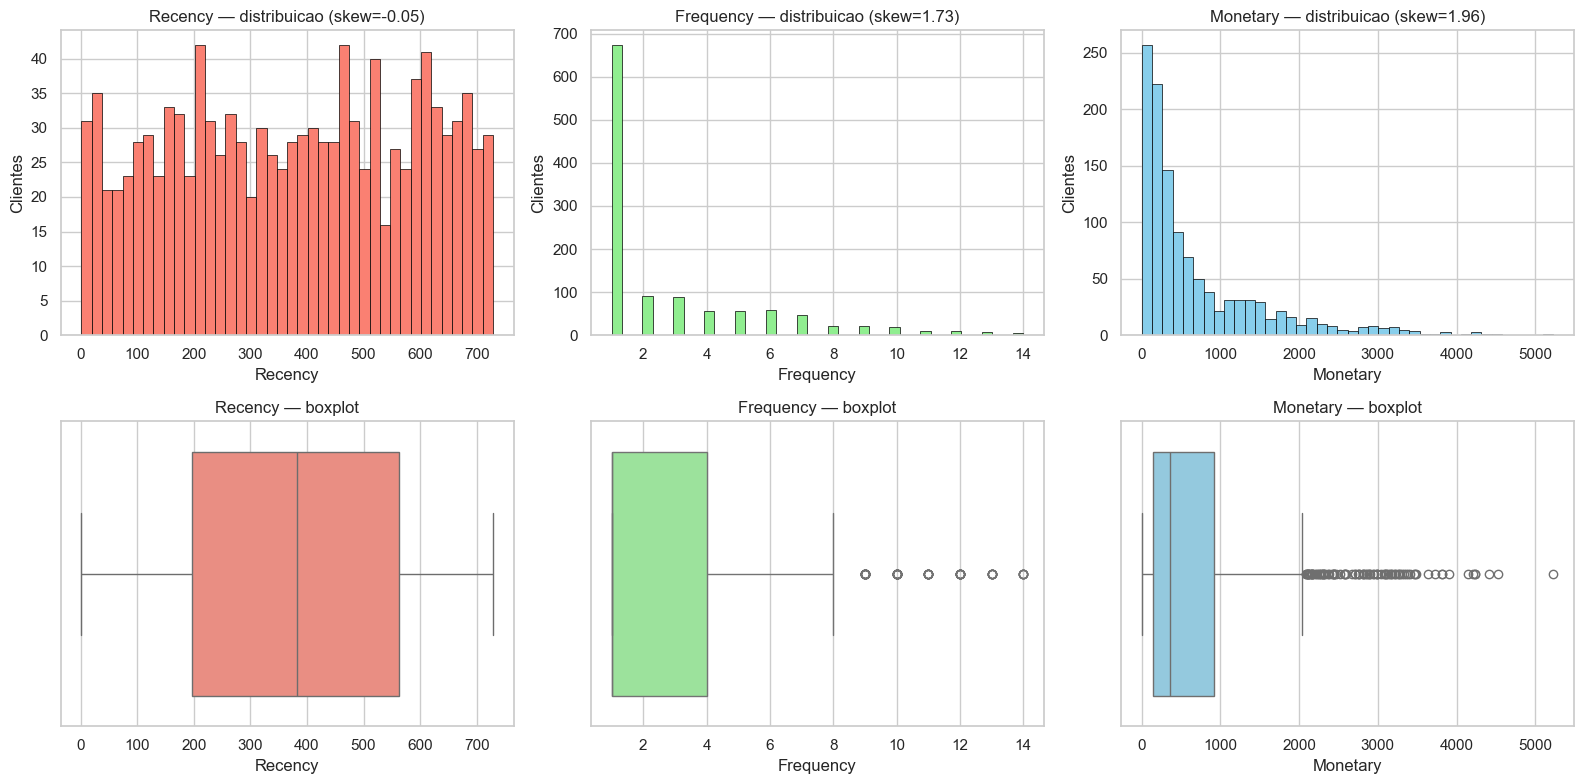

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

cores = {'Recency': 'salmon', 'Frequency': 'lightgreen', 'Monetary': 'skyblue'}
for i, m in enumerate(metricas):
    axes[0, i].hist(rfm[m], bins=40, color=cores[m], edgecolor='black', linewidth=0.5)
    axes[0, i].set_title(f'{m} — distribuicao (skew={rfm[m].skew():.2f})')
    axes[0, i].set_xlabel(m)
    axes[0, i].set_ylabel('Clientes')

    sns.boxplot(x=rfm[m], ax=axes[1, i], color=cores[m])
    axes[1, i].set_title(f'{m} — boxplot')
    axes[1, i].set_xlabel(m)

plt.tight_layout()
plt.show()

**Explicação do bloco**

- `plt.subplots(2, 3, figsize=(16, 8))` — devolve a figura e uma matriz 2×3 de eixos.
  Organizar como matriz (e não seis chamadas de `plt.subplot`) permite indexar
  `axes[linha, coluna]` dentro do laço, o que elimina a repetição literal de código que
  os blocos originais tinham (três histogramas e três boxplots escritos à mão, um a um).
- Linha superior: histogramas com `bins=40`. Mais bins que o padrão porque o objetivo
  aqui é enxergar a **forma** da cauda, não ter uma silhueta suave.
- Linha inferior: boxplots da mesma variável, alinhados coluna a coluna. Histograma e
  boxplot respondem coisas diferentes — o histograma mostra onde está a massa, o boxplot
  mostra a posição dos quartis e a extensão da cauda em relação a eles. Lado a lado, um
  explica o outro.
- `skew` no título de cada histograma — coloca o número junto da imagem para que a
  leitura visual e a medida não fiquem em lugares diferentes do notebook.

**Como ler estes gráficos:**

- **Recency** tende a ser a mais bem comportada — é uma contagem de dias espalhada por
  toda a janela de observação. É a variável em que os quantis funcionam sem ressalva.
- **Frequency** deve mostrar uma barra dominante no valor 1 e cauda curta. Essa forma é
  exatamente a que quebra os quintis.
- **Monetary** deve mostrar forte assimetria à direita, com a caixa do boxplot espremida
  à esquerda e muitos pontos além do bigode superior. Esses pontos são clientes reais de
  alto valor, não erro de medição.

## 10. Criação dos scores

Cada variável vira uma nota de 1 a `N_SCORES` (=5 aqui). Esta é a etapa com mais
decisões metodológicas da análise, e aplicar `qcut` automaticamente porque "é o que se
usa em RFM" seria exatamente o erro que este notebook quer evitar.

### 10.1 A lógica da Recência é invertida

Frequência e Monetário são "quanto maior, melhor": gastar mais, comprar mais vezes.
Recência é o oposto — **quanto menor, melhor**, porque poucos dias desde a última compra
significa cliente ativo.

Se a inversão não for feita, o score R fica com o sinal trocado em relação a F e M, e
qualquer combinação dos três (soma, média, padrão) passa a misturar sinais opostos,
produzindo segmentos sem sentido.

Duas implementações equivalentes apareceram no material desenvolvido:

```python
# Pipeline 1 — inversão via ordem dos rótulos
pd.qcut(recency, q=5, labels=range(5, 0, -1))

# Pipeline 3 — inversão via lógica condicional
if p == 'Recency':
    if x <= d[p][0.25]: return 4   # quartil mais recente recebe a maior nota
```

Ambas estão corretas. A primeira foi adotada por ser declarativa: `qcut` sempre rotula
os bins em ordem crescente do valor, então passar os rótulos ao contrário
(`[5,4,3,2,1]`) faz o bin de menor recência receber 5. Uma linha, sem ramificação.

### 10.2 Método de discretização: as opções e quando cada uma é melhor

| Método | Como funciona | Vantagem | Problema | Quando é a melhor escolha |
|---|---|---|---|---|
| **Quantis** (`pd.qcut`) | Bordas nos percentis; grupos de tamanho igual | Scores comparáveis entre dimensões; robusto a outliers | Falha com `Bin edges must be unique` quando há empate nas bordas | Variável contínua e bem espalhada — **Recência e Monetário** |
| **Cortes fixos** (`pd.cut`) | Bordas definidas por regra de negócio | Cada score significa algo concreto ("comprou 1 vez") | Grupos de tamanhos desiguais | Variável discreta com massa concentrada — **Frequência** |
| **Quantis sobre rank** | `rank(method='first')` antes do `qcut` | Sempre produz grupos iguais | Desempata pela ordem das linhas: clientes idênticos recebem notas diferentes | Último recurso, quando grupos iguais são requisito e não há regra de negócio disponível |

**Sobre os empates.** O material desenvolvido continha as duas formas de errar aqui.
`pd.qcut` direto sobre Frequência **quebra com exceção** — o que ao menos é visível.
A função `RScore` com quantis manuais e `.apply()` **não quebra**: quando os percentis
25% e 50% valem ambos 1, todo cliente com uma compra satisfaz a primeira condição e cai
na nota mais baixa, produzindo grupos completamente desbalanceados em silêncio. O erro
silencioso é o pior dos dois, porque sobrevive até a apresentação dos resultados.

A implementação abaixo **testa** a viabilidade dos quantis antes de aplicá-los e escolhe
o método por variável, registrando qual foi usado.

### 10.3 Quantos grupos?

O número de grupos (`N_SCORES`) controla a resolução da análise. Mais grupos separam
melhor, mas exigem que a variável tenha variação suficiente para sustentar a divisão.
Na escala de 5, o score somado varia de 3 a 15; na escala de 4 usada no Pipeline 3, de
3 a 12 — e é por isso que reaproveitar cortes de segmento entre escalas diferentes
produz grupos desbalanceados, como discutido na seção 2.2.

A alternativa de 4 grupos é preferível quando a base é pequena (poucos milhares de
clientes) ou quando a Frequência tem pouquíssimos valores distintos: com 5 grupos, dois
deles acabariam representando a mesma realidade de negócio. Aqui a escala está
parametrizada, então essa troca custa uma linha.

### 10.4 Outliers e clientes extremos

Como estabelecido na seção 2.3, nenhum cliente é removido. Vale reforçar o motivo
estatístico: por serem baseados em posição, os quantis são **naturalmente robustos** a
valores extremos — um cliente que gasta 100× a mediana ocupa exatamente uma posição no
ranking, igual a qualquer outro. O score monetário 5 significa "está entre os 20% que
mais gastam", e isso continua verdadeiro com ou sem outliers na base.

### 10.5 Interpretação dos scores

O score é **relativo à base, não absoluto**. `M=5` não significa "gasta muito" em termos
universais; significa "está no quintil superior de gasto *desta* base *neste* período".
Duas consequências práticas: (a) comparar scores entre períodos ou entre empresas
diferentes não faz sentido sem recalcular; (b) por construção, ~20% dos clientes sempre
terão `M=5`, mesmo que a receita total caia pela metade. Um score não mede saúde do
negócio — mede posição relativa dentro dele.

In [10]:
def pontuar(serie, n=N_SCORES, maior_melhor=True, cortes_fixos=None):
    """Discretiza uma serie em n notas, escolhendo o metodo conforme a distribuicao.

    Ordem de preferencia: quantis -> cortes fixos -> quantis sobre rank.
    Devolve (scores_int, nome_do_metodo) para que a escolha fique registrada.
    """
    labels = list(range(1, n + 1)) if maior_melhor else list(range(n, 0, -1))

    bordas = serie.quantile(np.linspace(0, 1, n + 1)).values
    if len(np.unique(bordas)) == n + 1:
        return pd.qcut(serie, q=n, labels=labels).astype(int), 'quantis'

    if cortes_fixos is not None and len(cortes_fixos) == n + 1:
        scores = pd.cut(serie, bins=cortes_fixos, labels=labels)
        if scores.isna().any():
            raise ValueError('cortes fixos nao cobrem toda a amplitude da variavel')
        return scores.astype(int), 'cortes fixos'

    return pd.qcut(serie.rank(method='first'), q=n, labels=labels).astype(int), 'quantis sobre rank'


metodos = {}
rfm['R'], metodos['R'] = pontuar(rfm['Recency'], maior_melhor=False)
rfm['F'], metodos['F'] = pontuar(rfm['Frequency'], cortes_fixos=CORTES_FREQUENCIA)
rfm['M'], metodos['M'] = pontuar(rfm['Monetary'])

rfm['RFM_Score'] = rfm[['R', 'F', 'M']].sum(axis=1)
rfm['RFM_Group'] = (rfm['R'].astype(str) + '-' + rfm['F'].astype(str) + '-' + rfm['M'].astype(str))

print('METODO DE DISCRETIZACAO POR DIMENSAO')
print('-' * 50)
for dim, metodo in metodos.items():
    print(f'  {dim}: {metodo}')

print(f'\nAmplitude do score somado: {rfm["RFM_Score"].min()} a {rfm["RFM_Score"].max()} '
      f'(teorico: {3 * 1} a {3 * N_SCORES})')

print('\nDISTRIBUICAO DOS CLIENTES POR NOTA')
print('-' * 50)
dist = pd.DataFrame({d: rfm[d].value_counts(normalize=True).sort_index() * 100 for d in ['R', 'F', 'M']})
print(dist.round(1).to_string())

print('\nCOERENCIA DOS CORTES (valor real por nota)')
print('-' * 50)
for dim, var in [('R', 'Recency'), ('F', 'Frequency'), ('M', 'Monetary')]:
    faixas = rfm.groupby(dim)[var].agg(['min', 'max', 'count'])
    print(f'\n{var} (metodo: {metodos[dim]}):')
    print(faixas.to_string())

METODO DE DISCRETIZACAO POR DIMENSAO
--------------------------------------------------
  R: quantis
  F: cortes fixos
  M: quantis

Amplitude do score somado: 3 a 15 (teorico: 3 a 15)

DISTRIBUICAO DOS CLIENTES POR NOTA
--------------------------------------------------
      R     F     M
1 20.10 57.80 20.10
2 19.90  7.80 20.00
3 20.00  7.60 20.00
4 20.00  9.80 20.00
5 20.10 17.10 20.10

COERENCIA DOS CORTES (valor real por nota)
--------------------------------------------------

Recency (metodo: quantis):
   min  max  count
R                 
1  598  729    234
2  456  597    232
3  302  455    233
4  160  300    233
5    1  159    235

Frequency (metodo: cortes fixos):
   min  max  count
F                 
1    1    1    674
2    2    2     91
3    3    3     89
4    4    5    114
5    6   14    199

Monetary (metodo: quantis):
       min      max  count
M                         
1     1.10   119.25    234
2   119.48   253.82    233
3   253.84   497.46    233
4   498.21 1,214.23 

**Explicação do bloco**

- `labels = list(range(1, n+1)) if maior_melhor else list(range(n, 0, -1))` — a inversão
  da Recência acontece aqui, e em nenhum outro lugar. Para `maior_melhor=False` os
  rótulos saem `[5,4,3,2,1]`; como o `qcut` atribui rótulos na ordem crescente dos bins,
  o bin de menor recência (compra mais recente) recebe o primeiro rótulo da lista, que é
  5. Concentrar a inversão num único ponto evita o risco de ela ser aplicada duas vezes
  ou esquecida.
- `bordas = serie.quantile(np.linspace(0, 1, n+1)).values` seguido de
  `len(np.unique(bordas)) == n + 1` — **o teste que decide o método**. Calcula
  exatamente as bordas que o `qcut` usaria e verifica se são distintas. Se forem, o
  `qcut` é seguro; se não, sabemos disso *antes* da exceção.
- `pd.cut(serie, bins=cortes_fixos, labels=labels)` — caminho alternativo. Diferente do
  `qcut`, o `cut` recebe as bordas explicitamente, então empates não são problema: vários
  clientes podem cair no mesmo bin sem nenhum conflito. O preço é que os grupos ficam de
  tamanhos diferentes.
- `if scores.isna().any(): raise ValueError(...)` — `pd.cut` devolve `NaN` para valores
  fora das bordas, e `.astype(int)` sobre `NaN` levantaria um erro obscuro de conversão.
  Verificar antes e lançar mensagem explícita transforma uma falha críptica em
  diagnóstico útil.
- `serie.rank(method='first')` no último recurso — converte os valores em posições
  1, 2, 3…, todas distintas, o que garante bordas únicas. `method='first'` desempata pela
  ordem de aparição, e é justamente por ser **arbitrário** que este caminho é o último da
  fila: dois clientes com a mesma frequência podem receber notas diferentes sem nenhuma
  razão de negócio.
- A função devolver `(scores, metodo)` em vez de só os scores é o que permite auditar a
  escolha. Sem isso, o leitor não teria como saber qual dos três caminhos foi tomado em
  cada dimensão.
- `rfm[['R','F','M']].sum(axis=1)` — `axis=1` soma ao longo das colunas, linha a linha.
  Como as colunas já são inteiras (`.astype(int)` dentro de `pontuar`), a soma é direta.
  Isso resolve preventivamente o atrito com o tipo `category` que o `qcut` devolve por
  padrão quando `labels` é passado, e que em versões mais antigas do pandas impede
  operações aritméticas.
- `rfm['RFM_Group']` — concatenação com `.astype(str)`, produzindo rótulos como `'5-1-2'`.
  Ao contrário da soma, o grupo **preserva o padrão**: `5-1-1` e `1-4-2` somam 7 os dois,
  mas são strings distintas. É essa coluna que sustenta a segmentação da seção 11.
- O bloco final de "coerência dos cortes" agrupa por nota e mostra o mínimo e o máximo da
  variável original em cada uma. É a verificação que expõe corte arbitrário: se duas
  notas diferentes mostrarem `min == max == 1` em Frequência, clientes idênticos foram
  separados sem motivo — o sintoma exato do caminho por rank.

## 11. Segmentação dos clientes

### A regra

Conforme a decisão da seção 2.4, a segmentação usa o **padrão** R/F/M, não a soma. As
regras operam sobre três faixas derivadas da escala:

- **alto** = nota ≥ `N_SCORES - 1` (com escala 5: notas 4 e 5 — os 40% superiores)
- **baixo** = nota ≤ 2 (os 40% inferiores)
- **médio** = o que sobra (nota 3)

As regras são avaliadas **em ordem** e são mutuamente exclusivas e exaustivas — todo
cliente recebe exatamente um rótulo:

| # | Regra | Segmento | Justificativa do nome |
|---|---|---|---|
| 1 | R alto **e** F alto **e** M alto | **VIP/Loyal** | Ativo, frequente e valioso nas três dimensões |
| 2 | R baixo **e** F alto **e** M alto | **Can't Lose** | Foi dos melhores clientes e parou de comprar — maior perda potencial da base |
| 3 | R baixo **e** (F alto **ou** M alto) | **At Risk Customers** | Tinha bom histórico em pelo menos uma dimensão e esfriou |
| 4 | R baixo **e** F baixo **e** M baixo | **Lost** | Sem atividade recente e sem histórico relevante |
| 5 | R alto (demais casos) | **Potential Loyal** | Comprou recentemente mas ainda não consolidou frequência/valor |
| 6 | restante | **Regular** | Não apresenta padrão extremo em nenhuma dimensão |

Os nomes vêm do código desenvolvido na conversa (`RFM_Customer_Segments`). Os slides
usavam nomes equivalentes — Champions, Loyal Regulars, Promising Newbies, At-Risk,
Lost Causes — mantidos aqui apenas como referência conceitual, já que os rótulos do
código são os que estão implementados. A regra 6 ("Regular") é um resíduo necessário:
sem ela, clientes de comportamento mediano ficariam sem classificação.

### A comparação com a segmentação por soma

A regra por soma (`RFM_Segment_Label`: Low/Mid/High-Value) desenvolvida na conversa é
mantida como **segunda coluna**, para que a diferença entre os dois métodos seja
mensurável e não apenas argumentada. Os cortes, porém, foram recalculados: em vez dos
limites fixos `<5` e `<9` — calibrados para a escala 1–4, onde "Low-Value" acabava
cobrindo apenas os scores 3 e 4 — usam-se os **terços da distribuição observada**, o que
funciona em qualquer escala e produz grupos equilibrados.

In [11]:
LIMIAR_ALTO = N_SCORES - 1   # com N_SCORES=5: notas 4 e 5
LIMIAR_BAIXO = 2             # notas 1 e 2

ORDEM_SEGMENTOS = ['VIP/Loyal', 'Potential Loyal', 'Regular',
                   "Can't Lose", 'At Risk Customers', 'Lost']


def segmentar_por_padrao(linha):
    """Aplica as seis regras da tabela acima, na ordem, ao padrao R/F/M do cliente."""
    r, f, m = linha['R'], linha['F'], linha['M']
    r_alto, r_baixo = r >= LIMIAR_ALTO, r <= LIMIAR_BAIXO
    f_alto, m_alto = f >= LIMIAR_ALTO, m >= LIMIAR_ALTO
    f_baixo, m_baixo = f <= LIMIAR_BAIXO, m <= LIMIAR_BAIXO

    if r_alto and f_alto and m_alto:
        return 'VIP/Loyal'
    if r_baixo and f_alto and m_alto:
        return "Can't Lose"
    if r_baixo and (f_alto or m_alto):
        return 'At Risk Customers'
    if r_baixo and f_baixo and m_baixo:
        return 'Lost'
    if r_alto:
        return 'Potential Loyal'
    return 'Regular'


rfm['Segmento'] = rfm.apply(segmentar_por_padrao, axis=1)
rfm['Segmento'] = pd.Categorical(rfm['Segmento'], categories=ORDEM_SEGMENTOS, ordered=True)

# Segmentacao alternativa por soma, com cortes derivados da distribuicao observada
c1, c2 = rfm['RFM_Score'].quantile([1 / 3, 2 / 3])
rfm['RFM_Segment_Label'] = np.select(
    [rfm['RFM_Score'] <= c1, rfm['RFM_Score'] <= c2],
    ['Low-Value', 'Mid-Value'],
    default='High-Value',
)

assert rfm['Segmento'].notna().all(), 'algum cliente ficou sem segmento'

print(f'Cortes da faixa por soma (tercos observados): <= {c1:.0f} e <= {c2:.0f}\n')
print('CLIENTES POR SEGMENTO')
print('-' * 46)
contagem = rfm['Segmento'].value_counts().reindex(ORDEM_SEGMENTOS)
for seg, qtd in contagem.items():
    print(f'{seg:<20} {qtd:>7,}  {qtd / len(rfm) * 100:>6.1f}%')

print('\nONDE OS DOIS METODOS DISCORDAM')
print('-' * 46)
cruzamento = pd.crosstab(rfm['Segmento'], rfm['RFM_Segment_Label'])
print(cruzamento.to_string())

Cortes da faixa por soma (tercos observados): <= 6 e <= 9

CLIENTES POR SEGMENTO
----------------------------------------------
VIP/Loyal                166    14.2%
Potential Loyal          302    25.9%
Regular                  333    28.5%
Can't Lose                58     5.0%
At Risk Customers         85     7.3%
Lost                     223    19.1%

ONDE OS DOIS METODOS DISCORDAM
----------------------------------------------
RFM_Segment_Label  High-Value  Low-Value  Mid-Value
Segmento                                           
VIP/Loyal                 166          0          0
Potential Loyal            47         44        211
Regular                   101        145         87
Can't Lose                 54          0          4
At Risk Customers           4         16         65
Lost                        0        223          0


**Explicação do bloco**

- `LIMIAR_ALTO = N_SCORES - 1` — o limiar é **derivado da escala**, não escrito à mão.
  Com `N_SCORES=5` vale 4 (notas altas: 4 e 5); trocando para 4, vira 3 (notas altas:
  3 e 4). É exatamente esse acoplamento que faltava no material original, onde cortes
  calibrados para uma escala apareciam aplicados sobre outra.
- `segmentar_por_padrao` — as condições booleanas (`r_alto`, `f_baixo`, …) são calculadas
  antes dos `if`, o que deixa cada regra legível como a linha correspondente da tabela.
  A **ordem dos `return` é a lógica**: a regra 2 ("Can't Lose") precisa vir antes da
  regra 3 ("At Risk"), porque quem tem F e M altos satisfaz as duas — e queremos o rótulo
  mais específico. Inverter essas duas linhas mudaria silenciosamente o resultado.
- O `return 'Regular'` final sem condição garante exaustividade: nenhum caminho sai da
  função sem rótulo.
- `rfm.apply(..., axis=1)` — aplica linha a linha. Aqui o `.apply` é justificável (a
  regra depende de três colunas simultaneamente e é ramificada); nos scores da seção 10
  ele não era, porque `qcut`/`cut` fazem o mesmo trabalho vetorizado e muito mais rápido.
- `pd.Categorical(..., categories=ORDEM_SEGMENTOS, ordered=True)` — converte o texto em
  categoria **com ordem definida**. Sem isso, todo `groupby` e todo gráfico ordenaria os
  segmentos alfabeticamente ("At Risk Customers" antes de "VIP/Loyal"), o que não tem
  significado de negócio. Com a ordem fixada, todas as tabelas e gráficos daqui em diante
  saem na sequência melhor → pior automaticamente.
- `np.select([cond1, cond2], [val1, val2], default=...)` — equivalente vetorizado a uma
  cadeia if/elif/else. As condições são avaliadas em ordem e a primeira verdadeira vence.
  É mais rápido e mais legível que o `.apply(assign_segment)` original.
- `rfm['RFM_Score'].quantile([1/3, 2/3])` — os cortes saem da **distribuição observada**,
  não de números fixos. Isso garante grupos aproximadamente equilibrados em qualquer
  escala de score.
- `pd.crosstab(...)` — tabela de contingência cruzando as duas segmentações. É o
  resultado que materializa o argumento da seção 2.4: procure a linha
  **"At Risk Customers"** e veja em quais faixas de valor esses clientes caem. Eles se
  espalham por faixas diferentes porque a soma não os reconhece como grupo — a
  informação "recência baixa com histórico alto" simplesmente não sobrevive a um total.

## 12. Perfil dos segmentos

Um segmento só é acionável quando se sabe **quantas pessoas ele contém, quanto dinheiro
representa e como esses dois números se relacionam**. A diferença entre as duas
participações — de clientes e de receita — é a informação mais importante da tabela: é
ela que revela a concentração típica de bases de varejo.

Média **e** mediana aparecem lado a lado por causa da assimetria medida na seção 9. Onde
as duas divergem muito, a média está sendo puxada por poucos clientes extremos e a
mediana descreve melhor o cliente típico daquele segmento.

In [12]:
perfil = rfm.groupby('Segmento', observed=True).agg(
    n_clientes=('Recency', 'size'),
    Recency_media=('Recency', 'mean'),
    Recency_mediana=('Recency', 'median'),
    Frequency_media=('Frequency', 'mean'),
    Frequency_mediana=('Frequency', 'median'),
    Monetary_media=('Monetary', 'mean'),
    Monetary_mediana=('Monetary', 'median'),
    receita_total=('Monetary', 'sum'),
    pedidos_total=('Frequency', 'sum'),
)

perfil['pct_clientes'] = perfil['n_clientes'] / perfil['n_clientes'].sum() * 100
perfil['pct_receita'] = perfil['receita_total'] / perfil['receita_total'].sum() * 100
perfil['ticket_medio'] = perfil['receita_total'] / perfil['pedidos_total']
perfil['receita_por_cliente'] = perfil['receita_total'] / perfil['n_clientes']

colunas = ['n_clientes', 'pct_clientes', 'receita_total', 'pct_receita',
           'Recency_mediana', 'Frequency_mediana', 'Monetary_mediana',
           'ticket_medio', 'receita_por_cliente']

print('PERFIL DOS SEGMENTOS')
print(perfil[colunas].round(1).to_string())

print('\nMEDIA vs MEDIANA (razao alta = segmento puxado por clientes extremos)')
print('-' * 62)
comparacao = pd.DataFrame({
    'Monetary_media': perfil['Monetary_media'],
    'Monetary_mediana': perfil['Monetary_mediana'],
    'razao': perfil['Monetary_media'] / perfil['Monetary_mediana'],
})
print(comparacao.round(2).to_string())

PERFIL DOS SEGMENTOS
                   n_clientes  pct_clientes  receita_total  pct_receita  Recency_mediana  Frequency_mediana  Monetary_mediana  ticket_medio  receita_por_cliente
Segmento                                                                                                                                                        
VIP/Loyal                 166         14.20     322,305.30        39.80           161.50               7.00          1,786.00        267.90             1,941.60
Potential Loyal           302         25.90      88,123.60        10.90           158.00               1.00            212.80        236.90               291.80
Regular                   333         28.50     223,276.60        27.60           413.00               1.00            381.10        249.20               670.50
Can't Lose                 58          5.00      82,224.30        10.20           522.50               6.00          1,277.50        227.10             1,417.70
At Risk Custo

**Explicação do bloco**

- `groupby('Segmento', observed=True)` — o `observed=True` importa porque `Segmento` é
  `Categorical`: sem ele, o pandas inclui categorias sem nenhum cliente como linhas de
  `NaN`, poluindo a tabela. Com ele, só aparecem segmentos efetivamente povoados.
- `n_clientes=('Recency', 'size')` — `size` conta linhas do grupo. A escolha da coluna é
  irrelevante para `size` (ao contrário de `count`, que ignora nulos); `Recency` está ali
  só porque a sintaxe de named aggregation exige uma coluna.
- `pedidos_total=('Frequency','sum')` — soma de pedidos do segmento. É o denominador
  correto do ticket médio.
- `ticket_medio = receita_total / pedidos_total` — **valor médio por pedido**, não por
  cliente. A distinção é analítica, não cosmética: um segmento pode ter receita por
  cliente alta por comprar *muitas vezes* (ticket baixo, frequência alta) ou por comprar
  *caro* (ticket alto, frequência baixa). São situações que pedem ações opostas —
  a primeira sugere programa de fidelidade, a segunda sugere recompra —, e só a
  comparação entre `ticket_medio` e `receita_por_cliente` separa as duas.
- `receita_por_cliente = receita_total / n_clientes` — a outra metade dessa leitura.
- `pct_clientes` e `pct_receita` calculadas como colunas separadas — colocar as duas na
  mesma tabela é o que permite ler a concentração de imediato: um segmento com 10% dos
  clientes e 40% da receita salta aos olhos.
- A tabela final `comparacao` com a razão média/mediana: valores próximos de 1 indicam
  segmento homogêneo, onde a média descreve bem seus membros. Razões altas indicam
  segmento internamente desigual, onde citar a média em uma apresentação seria enganoso.

## 13. Visualizações

Cada gráfico abaixo responde uma pergunta específica. Gráficos que apenas repetem em
forma de imagem o que a tabela da seção 12 já diz foram deixados de fora.

**Gráfico 1 — Clientes por segmento.** Pergunta: *qual o tamanho de cada grupo?* É a
base operacional de qualquer campanha: define quantas pessoas seriam impactadas.

**Gráfico 2 — Clientes × receita (%).** Pergunta: *onde estão as pessoas e onde está o
dinheiro?* O gráfico só é útil porque mostra as duas séries juntas — a distância entre as
barras de um mesmo segmento é a leitura.

**Gráfico 3 — Treemap da receita.** Pergunta: *como a receita se distribui dentro de cada
faixa de valor?* A área é proporcional à receita, o que torna a concentração visível
imediatamente. Usa a hierarquia faixa → segmento para conectar as duas segmentações.

**Gráfico 4 — R, F e M médios por segmento.** Pergunta: *os rótulos fazem sentido?* É uma
checagem de validade: se "VIP/Loyal" não aparecer alto nas três barras, a regra de
segmentação está errada.

In [13]:
# --- Grafico 1: clientes por segmento ---
contagem_df = (rfm['Segmento'].value_counts()
               .reindex(ORDEM_SEGMENTOS)
               .reset_index())
contagem_df.columns = ['Segmento', 'Clientes']

fig1 = px.bar(
    contagem_df, x='Segmento', y='Clientes',
    title='Clientes por segmento RFM',
    labels={'Clientes': 'Numero de clientes'},
    color='Segmento',
    category_orders={'Segmento': ORDEM_SEGMENTOS},
    color_discrete_sequence=px.colors.qualitative.Pastel,
    text='Clientes',
)
fig1.update_traces(texttemplate='%{text:,}', textposition='outside',
                   marker_line_color='rgb(8,48,107)', marker_line_width=1.2, opacity=0.85)
fig1.update_layout(showlegend=False, yaxis_title='Numero de clientes')
fig1.show()

**Explicação do bloco**

- `.value_counts().reindex(ORDEM_SEGMENTOS)` — o `reindex` força a ordem de negócio.
  Sem ele, o eixo sairia ordenado por contagem ou alfabeticamente, e o leitor perderia a
  narrativa "melhor → pior" que a sequência carrega.
- `.reset_index()` seguido de atribuição direta a `.columns` — converte a série em
  dataframe de duas colunas com nomes controlados. A atribuição posicional é usada aqui
  porque o nome que `reset_index()` gera para a coluna de contagem mudou entre versões do
  pandas; renomear por posição torna o código estável independentemente da versão.
- `category_orders={'Segmento': ORDEM_SEGMENTOS}` — reforça a ordem dentro do plotly.
  É redundante com o `reindex` por segurança: o plotly reordena categorias em algumas
  situações e essa é a instrução que ele respeita.
- `text='Clientes'` com `texttemplate='%{text:,}'` — imprime o valor sobre cada barra,
  com separador de milhar. Elimina a necessidade de o leitor estimar a altura contra o
  eixo.
- `marker_line_*` e `opacity` — contorno escuro e leve transparência, o mesmo tratamento
  visual usado nos gráficos desenvolvidos durante a conversa, mantido por consistência.
- Não há condição de destaque por nome de segmento aqui. No código original, um
  `segment == 'Champions'` tentava colorir um segmento que não existia na base — a
  comparação nunca era verdadeira e o destaque nunca aparecia. A cor por categoria
  (`color='Segmento'`) resolve o mesmo objetivo sem depender de string literal.

In [14]:
# --- Grafico 2: participacao de clientes vs participacao de receita ---
comp = perfil.reindex(ORDEM_SEGMENTOS).dropna(subset=['n_clientes'])

fig2 = go.Figure()
fig2.add_trace(go.Bar(x=comp.index.astype(str), y=comp['pct_clientes'],
                      name='% dos clientes', marker_color='rgb(158,202,225)'))
fig2.add_trace(go.Bar(x=comp.index.astype(str), y=comp['pct_receita'],
                      name='% da receita', marker_color='rgb(32,102,148)'))
fig2.update_layout(
    title='Participacao de clientes vs participacao de receita',
    xaxis_title='Segmento', yaxis_title='% do total',
    barmode='group', showlegend=True,
)
fig2.show()

**Explicação do bloco**

- `perfil.reindex(ORDEM_SEGMENTOS).dropna(subset=['n_clientes'])` — reordena e descarta
  segmentos vazios. O `dropna` é necessário porque o `reindex` cria linhas de `NaN` para
  qualquer segmento da lista que não exista nos dados.
- Duas chamadas de `add_trace` com `go.Bar` — uma série por barra. `graph_objects` é
  usado aqui em vez de `express` justamente porque as duas séries medem coisas diferentes
  (percentual de pessoas e percentual de dinheiro) e precisam ser declaradas
  separadamente; no `express` seria necessário derreter o dataframe para formato longo.
- `barmode='group'` — coloca as barras **lado a lado**, não empilhadas. Empilhar seria um
  erro conceitual aqui: somar "% de clientes" com "% de receita" não produz nada
  interpretável. A leitura pretendida é a **comparação** entre as duas alturas dentro de
  cada segmento.
- Cores em intensidade crescente (claro para clientes, escuro para receita) — reforça
  visualmente qual série é qual sem depender só da legenda.
- `comp.index.astype(str)` — converte o índice categórico para texto, evitando que o
  plotly aplique sua própria ordenação de categorias.

**Como interpretar:** barra escura muito mais alta que a clara significa segmento
pequeno em pessoas e grande em dinheiro — alto valor por cliente, e alto risco de
concentração. O padrão inverso indica um grupo numeroso de baixo valor individual, onde
ações caras por cliente não se pagam.

In [15]:
# --- Grafico 3: treemap da receita por faixa e segmento ---
receita_hierarquia = (rfm.groupby(['RFM_Segment_Label', 'Segmento'], observed=True)
                      .agg(Receita=('Monetary', 'sum'), Clientes=('Monetary', 'size'))
                      .reset_index())
receita_hierarquia = receita_hierarquia[receita_hierarquia['Receita'] > 0]
receita_hierarquia['Segmento'] = receita_hierarquia['Segmento'].astype(str)

fig3 = px.treemap(
    receita_hierarquia,
    path=['RFM_Segment_Label', 'Segmento'],
    values='Receita',
    color='RFM_Segment_Label',
    color_discrete_sequence=px.colors.qualitative.Pastel,
    custom_data=['Clientes'],
    title='Receita por faixa de valor e segmento',
)
fig3.update_traces(
    textinfo='label+percent parent',
    hovertemplate='<b>%{label}</b><br>Receita: %{value:,.0f}<br>Clientes: %{customdata[0]:,}<extra></extra>',
)
fig3.show()

**Explicação do bloco**

- `groupby(['RFM_Segment_Label', 'Segmento'], observed=True)` — agrupa pelos dois níveis
  simultaneamente, produzindo exatamente a estrutura hierárquica que o treemap espera.
- `values='Receita'` em vez de contagem de clientes — decisão deliberada. O gráfico 1 já
  responde "quantas pessoas"; repetir a mesma informação em outro formato seria criar
  gráfico por criar. Com receita, o treemap responde uma pergunta nova: *onde está o
  dinheiro dentro de cada faixa*.
- `receita_hierarquia[...['Receita'] > 0]` — o treemap exige valores positivos; áreas
  negativas não existem. O filtro evita erro de renderização.
- `.astype(str)` no `Segmento` — o plotly não lida bem com colunas `Categorical` em
  `path`. Converter para texto aqui, no fim do pipeline, é mais seguro do que abrir mão
  da categoria ordenada nas etapas anteriores.
- `path=['RFM_Segment_Label', 'Segmento']` — define a hierarquia: o primeiro nível vira
  os retângulos grandes (faixa de valor), o segundo as subdivisões internas (segmento).
  É a conexão visual entre as duas segmentações comparadas na seção 11.
- `textinfo='label+percent parent'` — mostra, em cada retângulo interno, a fatia que ele
  representa **do seu bloco pai**, não do total. Essa é a leitura útil: "dentro da faixa
  High-Value, quanto vem de VIP/Loyal".
- `custom_data` + `hovertemplate` — leva a contagem de clientes para o tooltip. Área e
  hover juntos mostram receita e pessoas ao mesmo tempo, o que evita interpretar um
  retângulo grande como "muitos clientes" quando pode ser poucos clientes de alto valor.
  O `<extra></extra>` remove a caixa lateral padrão do plotly.

In [16]:
# --- Grafico 4: perfil medio de R, F e M por segmento (validacao dos rotulos) ---
scores_medios = (rfm.groupby('Segmento', observed=True)[['R', 'F', 'M']]
                 .mean().reindex(ORDEM_SEGMENTOS).dropna())

fig4 = go.Figure()
for dim, nome, cor in [('R', 'Recencia (maior = mais recente)', 'rgb(158,202,225)'),
                       ('F', 'Frequencia', 'rgb(94,158,217)'),
                       ('M', 'Monetario', 'rgb(32,102,148)')]:
    fig4.add_trace(go.Bar(x=scores_medios.index.astype(str), y=scores_medios[dim],
                          name=nome, marker_color=cor))

fig4.update_layout(
    title='Score medio de R, F e M por segmento',
    xaxis_title='Segmento', yaxis_title=f'Score medio (1 a {N_SCORES})',
    barmode='group', showlegend=True,
    yaxis=dict(range=[0, N_SCORES]),
)
fig4.show()

print('Scores medios por segmento:')
print(scores_medios.round(2).to_string())

Scores medios por segmento:
                     R    F    M
Segmento                        
VIP/Loyal         4.49 4.74 4.83
Potential Loyal   4.51 1.23 2.31
Regular           2.54 2.19 3.19
Can't Lose        1.78 4.55 4.53
At Risk Customers 1.55 2.13 4.07
Lost              1.41 1.08 1.49


**Explicação do bloco**

- O laço sobre a lista de tuplas `(dimensão, nome, cor)` substitui três blocos
  `add_trace` praticamente idênticos — que era a forma do código original. Mesmo
  resultado, um ponto único de manutenção.
- `name='Recencia (maior = mais recente)'` — a legenda carrega a explicação da inversão.
  Sem esse lembrete, um leitor razoável olharia a barra alta de Recência em "VIP/Loyal" e
  concluiria o oposto do que o gráfico diz. Como as três barras estão na mesma escala e
  com a mesma polaridade ("maior é melhor" nas três), a comparação lado a lado é
  legítima — mas isso só é verdade **porque** a inversão foi feita na seção 10.
- `yaxis=dict(range=[0, N_SCORES])` — fixa o eixo na amplitude possível do score. Sem
  isso o plotly ajusta o eixo aos dados e diferenças pequenas parecem enormes. A escala
  fixa mantém a comparação honesta entre segmentos e entre execuções.
- `.reindex(ORDEM_SEGMENTOS).dropna()` — mesma ordenação de negócio dos gráficos
  anteriores, com remoção de segmentos vazios.

**Como interpretar — este é um gráfico de validação, não de resultado.** O que se espera:
"VIP/Loyal" alto nas três barras; "Lost" baixo nas três; "Can't Lose" e "At Risk
Customers" com Recência visivelmente baixa e Frequência/Monetário altos — o desenho
característico de quem era bom cliente e parou. Se esse padrão **não** aparecer, o
problema está na regra de segmentação, não nos dados, e a seção 11 precisa ser revista
antes de qualquer conclusão de negócio.

## 14. Insights

Os números abaixo são **calculados a partir da base carregada**, não escritos à mão.
Isso é deliberado: um notebook que traz conclusões fixas no texto continua exibindo a
conclusão antiga quando os dados mudam. Ao rodar sobre a base real, os fatos abaixo
passam a ser os fatos da base real.

A leitura é organizada em três camadas, que precisam ficar separadas:

- **Fato observado** — o que os dados dizem. Verificável, sem julgamento.
- **Interpretação possível** — a explicação mais provável para aquele fato. É hipótese,
  e outras explicações podem caber no mesmo número.
- **Implicação de negócio** — o que fazer a respeito, se a interpretação estiver certa.

> **Atenção na execução atual:** a base é sintética (seção 4). Os números impressos
> descrevem dados gerados, não o negócio. A estrutura do raciocínio é que é o
> entregável aqui.

In [17]:
def gerar_fatos(rfm, perfil):
    """Calcula os fatos quantitativos da base. Retorna dict para uso no texto."""
    f = {}
    total_receita = rfm['Monetary'].sum()
    n = len(rfm)

    # 1. Concentracao de receita: os 20% que mais gastam respondem por quanto?
    corte_top = rfm['Monetary'].quantile(0.8)
    f['pct_receita_top20'] = rfm.loc[rfm['Monetary'] >= corte_top, 'Monetary'].sum() / total_receita * 100

    # 2. Compradores de uma unica vez
    f['pct_uma_compra'] = (rfm['Frequency'] == 1).mean() * 100
    f['pct_receita_uma_compra'] = rfm.loc[rfm['Frequency'] == 1, 'Monetary'].sum() / total_receita * 100

    # 3. Receita em risco: clientes valiosos que pararam de comprar
    em_risco = rfm['Segmento'].isin(["Can't Lose", 'At Risk Customers'])
    f['pct_clientes_risco'] = em_risco.mean() * 100
    f['pct_receita_risco'] = rfm.loc[em_risco, 'Monetary'].sum() / total_receita * 100
    f['recencia_mediana_risco'] = rfm.loc[em_risco, 'Recency'].median()

    # 4. Segmento de maior valor por cliente
    rpc = perfil['receita_por_cliente'].dropna()
    f['seg_top_valor'] = str(rpc.idxmax())
    f['razao_valor_top_vs_base'] = rpc.max() / (total_receita / n)

    # 5. O valor do VIP vem de comprar MAIS VEZES ou de comprar MAIS CARO?
    if 'VIP/Loyal' in perfil.index and perfil.loc['VIP/Loyal', 'n_clientes'] > 0:
        f['vip_pct_clientes'] = perfil.loc['VIP/Loyal', 'pct_clientes']
        f['vip_pct_receita'] = perfil.loc['VIP/Loyal', 'pct_receita']
        ticket_geral = total_receita / rfm['Frequency'].sum()
        f['vip_razao_ticket'] = perfil.loc['VIP/Loyal', 'ticket_medio'] / ticket_geral
        f['vip_razao_frequencia'] = perfil.loc['VIP/Loyal', 'Frequency_media'] / rfm['Frequency'].mean()

    # 6. Assimetria entre participacao de clientes e de receita
    comp = perfil[['pct_clientes', 'pct_receita']].dropna()
    f['maior_gap'] = (comp['pct_receita'] - comp['pct_clientes']).abs().max()

    return f


fatos = gerar_fatos(rfm, perfil)

print('FATOS OBSERVADOS NA BASE CARREGADA')
print('=' * 68)
print(f'1. Os 20% de maior gasto concentram {fatos["pct_receita_top20"]:.1f}% da receita.')
print(f'2. {fatos["pct_uma_compra"]:.1f}% dos clientes compraram uma unica vez, '
      f'e respondem por {fatos["pct_receita_uma_compra"]:.1f}% da receita.')
print(f'3. Clientes em risco (Can\'t Lose + At Risk) sao {fatos["pct_clientes_risco"]:.1f}% da base '
      f'e {fatos["pct_receita_risco"]:.1f}% da receita;')
print(f'   estao ha {fatos["recencia_mediana_risco"]:.0f} dias (mediana) sem comprar.')
print(f'4. Maior receita por cliente: "{fatos["seg_top_valor"]}", '
      f'{fatos["razao_valor_top_vs_base"]:.1f}x a media da base.')
if 'vip_pct_clientes' in fatos:
    print(f'5. VIP/Loyal: {fatos["vip_pct_clientes"]:.1f}% dos clientes para '
          f'{fatos["vip_pct_receita"]:.1f}% da receita.')
    print(f'   O valor vem da recorrencia, nao do tamanho da compra: '
          f'compram {fatos["vip_razao_frequencia"]:.1f}x mais vezes que a media, '
          f'com ticket {fatos["vip_razao_ticket"]:.1f}x o ticket geral.')
print(f'6. Maior descolamento entre % de clientes e % de receita num mesmo segmento: '
      f'{fatos["maior_gap"]:.1f} pontos percentuais.')
print('=' * 68)

FATOS OBSERVADOS NA BASE CARREGADA
1. Os 20% de maior gasto concentram 60.1% da receita.
2. 57.8% dos clientes compraram uma unica vez, e respondem por 20.0% da receita.
3. Clientes em risco (Can't Lose + At Risk) sao 12.3% da base e 18.4% da receita;
   estao ha 570 dias (mediana) sem comprar.
4. Maior receita por cliente: "VIP/Loyal", 2.8x a media da base.
5. VIP/Loyal: 14.2% dos clientes para 39.8% da receita.
   O valor vem da recorrencia, nao do tamanho da compra: compram 2.6x mais vezes que a media, com ticket 1.1x o ticket geral.
6. Maior descolamento entre % de clientes e % de receita num mesmo segmento: 25.6 pontos percentuais.


**Explicação do bloco**

- A função devolve um **dicionário**, e o texto dos `print` consome esse dicionário. É o
  que garante que nenhum número apareça digitado no texto: se a base mudar, o texto muda
  junto. Um relatório em que o número é literal no texto é um relatório que fica errado
  sem avisar.
- `rfm['Monetary'].quantile(0.8)` e a soma acima desse corte — mede concentração de
  receita. Vale notar que este é um recorte por **quantil de gasto**, independente da
  segmentação: serve como verificação externa de que os segmentos não inventaram uma
  concentração que os dados não têm.
- `(rfm['Frequency'] == 1).mean() * 100` — proporção de compradores únicos. `.mean()`
  sobre booleano devolve a fração de `True`, multiplicada por 100 vira percentual. Esse
  número é o que sustenta (ou derruba) a decisão de discretização da seção 10: se for
  alto, os cortes fixos em Frequência eram obrigatórios.
- `rfm['Segmento'].isin([...])` — máscara para o conjunto "em risco". Somar receita sob
  a máscara e dividir pelo total dá a **receita em risco**, que é a tradução financeira
  direta do segmento.
- `perfil['receita_por_cliente'].idxmax()` — devolve o *rótulo* do segmento com maior
  valor por cliente, não o valor. É assim que o nome do segmento entra no texto sem ser
  digitado.
- `razao_valor_top_vs_base` — compara o melhor segmento com a média geral
  (`receita total / nº de clientes`). Uma razão expressa em "x vezes" é mais estável
  para leitura do que um valor absoluto, que depende de moeda e escala.
- `(comp['pct_receita'] - comp['pct_clientes']).abs().max()` — o maior descolamento, em
  pontos percentuais, entre participação de gente e participação de dinheiro. É a métrica
  resumida do Gráfico 2 da seção 13.
- `vip_razao_ticket` e `vip_razao_frequencia` — as duas juntas **decompõem** de onde vem
  o valor do melhor segmento. Receita por cliente é o produto de duas coisas muito
  diferentes: quanto se gasta por pedido (ticket) e quantas vezes se compra (frequência).
  Um segmento valioso por ticket alto e um valioso por recorrência alta pedem ações
  opostas, e a receita por cliente sozinha não distingue os dois. Calcular as duas razões
  contra a média geral transforma um número agregado em diagnóstico.
- O `if 'VIP/Loyal' in perfil.index` protege contra o caso em que nenhum cliente caiu
  nesse segmento — acessar `perfil.loc` de um rótulo inexistente levantaria `KeyError` e
  derrubaria o notebook inteiro por causa de uma linha de relatório.

### Leitura dos fatos

**Fato observado** — a receita é concentrada: uma minoria de clientes responde por uma
fatia desproporcional do faturamento, e o descolamento entre percentual de clientes e
percentual de receita aparece em vários segmentos.

**Interpretação possível** — é o padrão típico de varejo, em que poucos clientes
recorrentes sustentam o negócio enquanto a maioria compra uma vez e não volta. Também é
compatível com uma base jovem, em que boa parte dos clientes ainda não teve tempo de
recomprar — a distinção entre as duas exige olhar a data da primeira compra, que a
seção 15 discute.

**Implicação de negócio** — a verba de retenção tem retorno muito diferente conforme o
segmento. Perder um cliente do segmento de maior valor por cliente custa o equivalente a
perder vários clientes medianos, o que justifica tratamento diferenciado e custo de
retenção mais alto para esse grupo.

---

**Fato observado** — existe um grupo de clientes com frequência e valor altos cuja
recência é baixa (segmentos "Can't Lose" e "At Risk Customers"), e ele carrega uma fatia
da receita histórica bem maior que sua fatia de clientes.

**Interpretação possível** — são clientes que já demonstraram valor e pararam de comprar.
As causas possíveis são várias e os dados de RFM não as distinguem: insatisfação,
concorrência, mudança de necessidade ou simplesmente ciclo de recompra longo. Esta última
possibilidade é importante e frequentemente esquecida — um produto de recompra anual
produz "recência baixa" em clientes perfeitamente saudáveis.

**Implicação de negócio** — é o grupo com maior retorno esperado por contato, porque o
histórico já provou disposição a comprar. Antes de agir, porém, vale cruzar a recência
mediana do grupo com o ciclo de recompra típico do produto: se a recência estiver dentro
do ciclo normal, não há risco nenhum a tratar.

---

**Fato observado** — uma parcela relevante dos clientes tem exatamente uma compra.

**Interpretação possível** — pode indicar falha de reativação pós-primeira compra, ou
simplesmente que a base contém muitos clientes adquiridos recentemente, que ainda não
tiveram oportunidade de recomprar.

**Implicação de negócio** — as duas interpretações pedem ações opostas (corrigir a
jornada de recompra versus apenas aguardar), então este é um caso em que **agir antes de
separar os dois grupos é arriscado**. A separação é direta: comparar a data da primeira
compra desses clientes com o ciclo médio de recompra da base.

---

**Fato observado** — no segmento de maior valor, a razão de frequência contra a média da
base é muito maior que a razão de ticket. Ou seja: esses clientes não gastam mais *por
compra*, eles compram mais *vezes*.

**Interpretação possível** — o valor do melhor segmento vem de recorrência, não de
tamanho de cesta. Isso diz algo sobre o mecanismo do negócio: o que separa um cliente
valioso de um comum não é a capacidade de gastar num evento, é o hábito de voltar.

**Implicação de negócio** — ações de aumento de ticket (venda cruzada, kits, frete
grátis acima de um valor) atacam a alavanca errada neste segmento. A alavanca que
importa é a frequência: reduzir o intervalo entre compras vale mais do que aumentar o
valor de cada uma. Para outros segmentos a conclusão pode se inverter, e a mesma
decomposição responde qual é o caso.

---

**Fato observado** — o segmento com maior valor por cliente tem valor por cliente várias
vezes superior à média da base.

**Interpretação possível** — a média da base não descreve nenhum cliente real; ela é o
ponto entre dois comportamentos muito distintos.

**Implicação de negócio** — qualquer meta ou projeção construída sobre "o cliente médio"
vai errar nos dois extremos. Metas por segmento são mais informativas do que metas
globais.

## 15. Limitações

### Do método RFM

1. **Só enxerga o passado transacional.** RFM não conhece navegação, atendimento,
   satisfação, canal de aquisição ou exposição a campanha. Um cliente prestes a cancelar
   por insatisfação aparece como saudável até a compra parar.

2. **Não distingue ciclo de recompra.** Recência de 180 dias é alarmante para um produto
   de consumo mensal e absolutamente normal para um de recompra anual. Sem essa
   normalização, "At Risk" pode estar sinalizando clientes perfeitamente saudáveis.

3. **Scores são relativos e não comparáveis entre execuções.** Como discutido em 10.5,
   ~20% dos clientes terão sempre a nota máxima em Monetário, por construção. Se a
   receita total cair pela metade, a distribuição de scores permanece idêntica. **RFM
   mede posição relativa, não desempenho do negócio** — e por isso não serve como
   indicador de acompanhamento sem uma referência externa.

4. **Sem margem, "valor" é receita bruta.** Um cliente de alto volume e baixa margem é
   classificado como valioso. Com dados de custo, o Monetário deveria ser margem.

5. **A escolha dos cortes é convenção, não verdade.** Quintis, limiar "alto = 4 ou 5",
   cortes fixos de Frequência — são decisões defensáveis, documentadas e auditáveis, mas
   outras escolhas produziriam outra segmentação a partir dos mesmos dados.

### Dos dados desta análise

6. **Base sintética.** Como registrado na seção 4, os dados reais não foram fornecidos.
   Toda a estrutura de código é real e testada, mas nenhum número apresentado descreve
   um negócio real.

7. **Janela de observação finita.** Clientes cuja primeira compra ocorreu perto do fim da
   janela têm frequência estruturalmente subestimada; clientes ativos antes do início da
   base parecem novos. O campo `PrimeiraCompra` foi calculado na seção 8 justamente para
   permitir esse controle, que não é aplicado aqui por depender do ciclo de recompra real
   do negócio.

8. **Clientes não identificados são excluídos.** As transações sem `Customer ID` saem da
   análise. Se essa exclusão não for aleatória — por exemplo, se um canal específico
   registra menos o cliente — a base analisada fica enviesada em relação à base real.

### Sobre o caminho de clustering

Durante o desenvolvimento foi construído um pipeline alternativo que, no lugar de scores
por quantil, padronizava as variáveis com `StandardScaler` e aplicava `KMeans`, usando
inércia e silhueta para escolher o número de clusters. Ele **não** foi incorporado a este
notebook, por três razões:

- **Responde outra pergunta.** Scores respondem "onde este cliente está em relação aos
  outros, em cada dimensão"; clustering responde "que grupos naturais existem nos dados".
  Misturar os dois na mesma entrega confunde a leitura.
- **Perde a auditabilidade.** A regra da seção 11 pode ser lida e contestada por qualquer
  pessoa de negócio. Um centroide não.
- **Exige pré-processamento incompatível.** Sendo baseado em distância, o KMeans requer a
  remoção de outliers e o tratamento da assimetria (`StandardScaler` normaliza a escala
  mas **não** corrige assimetria — uma transformação logarítmica antes seria necessária)
  — exatamente os passos que, como argumentado em 2.3, seriam prejudiciais a um score por
  quantil.

É um caminho válido e complementar, recomendado como etapa seguinte quando a pergunta for
descobrir grupos não antecipados, e não classificar clientes em faixas conhecidas.

## 16. Código completo

Versão consolidada e autossuficiente de toda a análise. Este bloco **não depende de
nenhuma célula anterior** — pode ser copiado para um arquivo `.py` e executado
diretamente. É o mesmo pipeline das seções 3 a 13, reorganizado em funções com
separação explícita entre preparação, cálculo, pontuação, segmentação e análise.

Para rodar com dados reais, substitua a chamada de `gerar_base_sintetica()` por
`pd.read_csv(...)` na seção marcada.

CHECAGEM                               QTD         %
----------------------------------------------------
Sem Customer ID                        185     1.80%
Quantity nula                            0     0.00%
Price nulo                               0     0.00%
Linhas duplicadas                      102     0.99%
Quantity <= 0 (devolucao)              355     3.45%
Price <= 0                              61     0.59%
----------------------------------------------------

Preparacao: 10,293 -> 9,948 linhas, 1,196 clientes

Data de referencia: 10/12/2011
Metodo de discretizacao: {'R': 'quantis', 'F': 'cortes fixos', 'M': 'quantis'}
Clientes analisados: 1,167 (isolados por saldo negativo: 0)

PERFIL DOS SEGMENTOS
                   n_clientes  pct_clientes  receita_total  pct_receita  Recency_mediana  Frequency_mediana  Monetary_mediana  ticket_medio  receita_por_cliente
Segmento                                                                                                             

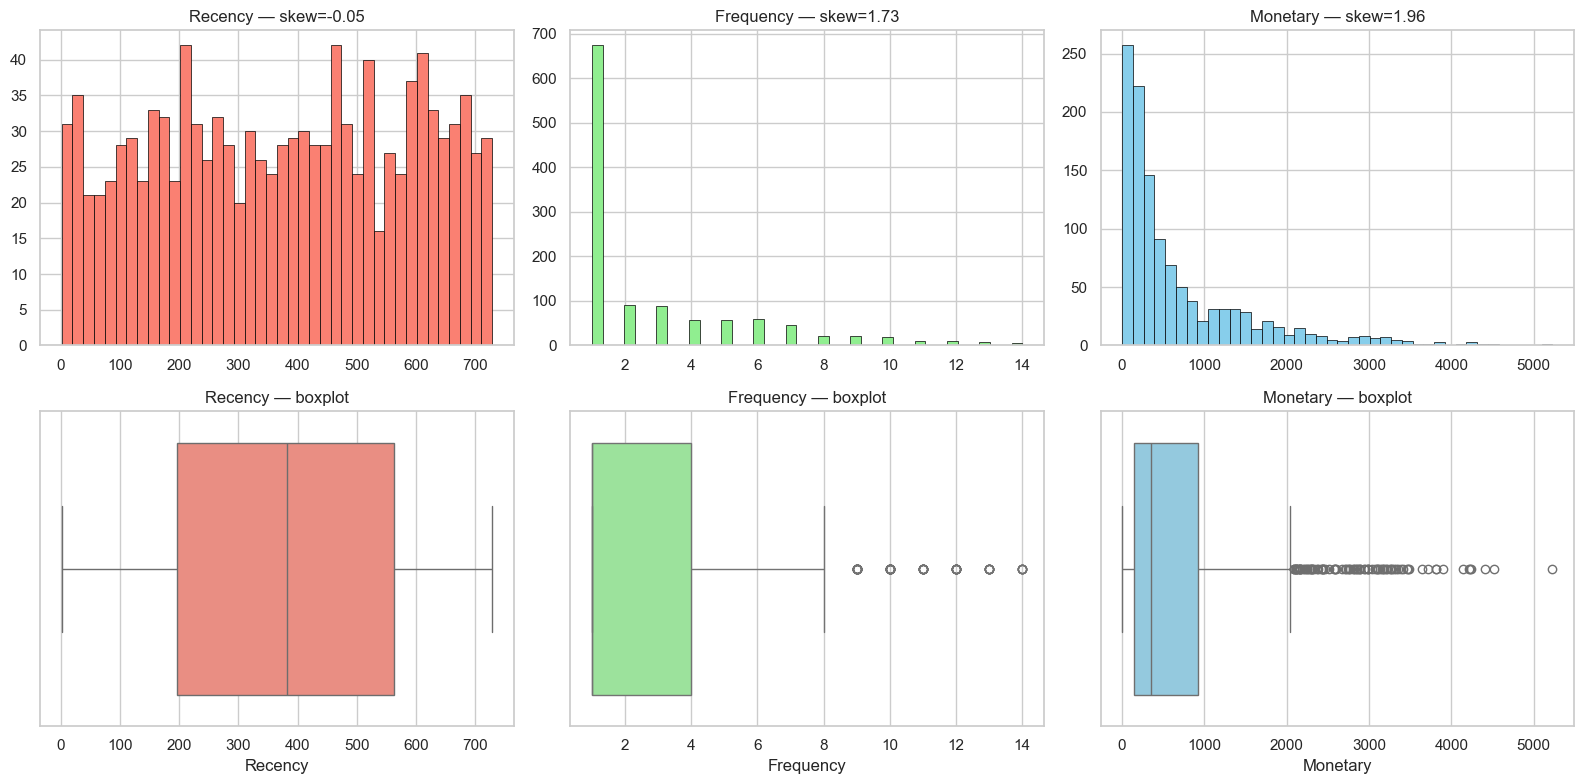

In [18]:
"""
ANALISE RFM — SEGMENTACAO DE CLIENTES
Pipeline consolidado: preparacao -> calculo RFM -> scores -> segmentacao -> analise.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

pd.set_option('display.float_format', lambda v: f'{v:,.2f}')
sns.set_theme(style='whitegrid')

# ---------------------------------------------------------------- parametros
N_SCORES = 5                                  # escala dos scores (1..N)
CORTES_FREQUENCIA = [0, 1, 2, 3, 5, np.inf]   # plano B para Frequencia (N=5)
LIMIAR_ALTO = N_SCORES - 1
LIMIAR_BAIXO = 2
SEED = 42
ORDEM_SEGMENTOS = ['VIP/Loyal', 'Potential Loyal', 'Regular',
                   "Can't Lose", 'At Risk Customers', 'Lost']


# ------------------------------------------------------------------- dados
def gerar_base_sintetica(n_clientes=1200, seed=SEED):
    """ASSUMPTION: base real nao disponivel. Substituir por pd.read_csv(...)."""
    rng = np.random.default_rng(seed)
    fim_janela = pd.Timestamp('2011-12-09')
    linhas, invoice = [], 500000
    for cliente in range(1, n_clientes + 1):
        dias_desde_ultima = int(rng.integers(0, 730))
        n_pedidos = 1 if rng.random() < 0.55 else int(rng.integers(2, 15))
        intervalo = int(rng.integers(10, 120))
        for p in range(n_pedidos):
            offset = dias_desde_ultima + p * intervalo
            if offset > 729:
                break
            invoice += 1
            data = fim_janela - pd.Timedelta(days=offset) + pd.Timedelta(hours=int(rng.integers(8, 19)))
            devolucao = rng.random() < 0.04
            for _ in range(int(rng.integers(1, 6))):
                qtd = -int(rng.integers(1, 5)) if devolucao else int(rng.integers(1, 15))
                preco = round(float(rng.lognormal(mean=2.0, sigma=0.9)), 2)
                linhas.append((cliente, str(invoice), data, qtd, preco))

    df = pd.DataFrame(linhas, columns=['Customer ID', 'Invoice', 'InvoiceDate', 'Quantity', 'Price'])
    df.loc[df.sample(frac=0.018, random_state=1).index, 'Customer ID'] = np.nan
    df.loc[df.sample(frac=0.006, random_state=2).index, 'Price'] = 0.0
    df = pd.concat([df, df.sample(frac=0.01, random_state=3)], ignore_index=True)
    return df.sample(frac=1, random_state=4).reset_index(drop=True)


# ------------------------------------------------------------ data quality
def diagnosticar_qualidade(df):
    """Mede problemas na base. Nao altera nada."""
    n = len(df)
    checagens = {
        'Sem Customer ID': df['Customer ID'].isna(),
        'Quantity nula': df['Quantity'].isna(),
        'Price nulo': df['Price'].isna(),
        'Linhas duplicadas': df.duplicated(),
        'Quantity <= 0 (devolucao)': df['Quantity'] <= 0,
        'Price <= 0': df['Price'] <= 0,
    }
    print(f'{"CHECAGEM":<32}{"QTD":>10}{"%":>10}')
    print('-' * 52)
    for rotulo, mascara in checagens.items():
        qtd = int(mascara.sum())
        print(f'{rotulo:<32}{qtd:>10,}{qtd / n * 100:>9.2f}%')
    print('-' * 52)


# -------------------------------------------------------------- preparacao
def preparar_dados(df):
    """Remove o inutilizavel, marca devolucoes e cria o valor por linha."""
    log = {'linhas_iniciais': len(df)}

    df = df.dropna(subset=['Customer ID', 'InvoiceDate', 'Quantity', 'Price']).copy()
    df = df.drop_duplicates()
    df['Customer ID'] = df['Customer ID'].astype('int64')
    df['LineTotal'] = df['Quantity'] * df['Price']

    # Devolucao e marcada, nao removida: entra no Monetario liquido, sai de Frequency.
    df['eh_devolucao'] = df['Quantity'] < 0
    df = df[~((df['Price'] <= 0) & (~df['eh_devolucao']))]

    log['linhas_finais'] = len(df)
    log['clientes'] = df['Customer ID'].nunique()
    return df, log


# -------------------------------------------------------------- calculo RFM
def calcular_rfm(df):
    """Recency/Frequency sobre compras efetivas; Monetary liquido (com devolucoes)."""
    reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
    compras = df[~df['eh_devolucao']]

    monetario = df.groupby('Customer ID').agg(Monetary=('LineTotal', 'sum'))
    atividade = compras.groupby('Customer ID').agg(
        Frequency=('Invoice', 'nunique'),
        UltimaCompra=('InvoiceDate', 'max'),
        PrimeiraCompra=('InvoiceDate', 'min'),
    )

    rfm = monetario.join(atividade, how='inner')
    rfm['Recency'] = (reference_date - rfm['UltimaCompra']).dt.days
    rfm['TicketMedio'] = rfm['Monetary'] / rfm['Frequency']

    saldo_negativo = rfm[rfm['Monetary'] <= 0].copy()
    rfm = rfm[rfm['Monetary'] > 0].copy()

    assert rfm['Recency'].ge(0).all()
    assert rfm['Frequency'].ge(1).all()
    return rfm, saldo_negativo, reference_date


# ----------------------------------------------------------------- scores
def pontuar(serie, n=N_SCORES, maior_melhor=True, cortes_fixos=None):
    """Quantis -> cortes fixos -> quantis sobre rank. Devolve (scores, metodo)."""
    labels = list(range(1, n + 1)) if maior_melhor else list(range(n, 0, -1))

    bordas = serie.quantile(np.linspace(0, 1, n + 1)).values
    if len(np.unique(bordas)) == n + 1:
        return pd.qcut(serie, q=n, labels=labels).astype(int), 'quantis'

    if cortes_fixos is not None and len(cortes_fixos) == n + 1:
        scores = pd.cut(serie, bins=cortes_fixos, labels=labels)
        if scores.isna().any():
            raise ValueError('cortes fixos nao cobrem a amplitude da variavel')
        return scores.astype(int), 'cortes fixos'

    return pd.qcut(serie.rank(method='first'), q=n, labels=labels).astype(int), 'quantis sobre rank'


def aplicar_scores(rfm):
    """Recency e invertida: menor recencia recebe a maior nota."""
    metodos = {}
    rfm['R'], metodos['R'] = pontuar(rfm['Recency'], maior_melhor=False)
    rfm['F'], metodos['F'] = pontuar(rfm['Frequency'], cortes_fixos=CORTES_FREQUENCIA)
    rfm['M'], metodos['M'] = pontuar(rfm['Monetary'])
    rfm['RFM_Score'] = rfm[['R', 'F', 'M']].sum(axis=1)
    rfm['RFM_Group'] = rfm['R'].astype(str) + '-' + rfm['F'].astype(str) + '-' + rfm['M'].astype(str)
    return rfm, metodos


# ------------------------------------------------------------- segmentacao
def segmentar_por_padrao(linha):
    """Regras sobre o PADRAO R/F/M — a soma nao distingue perfis opostos."""
    r, f, m = linha['R'], linha['F'], linha['M']
    r_alto, r_baixo = r >= LIMIAR_ALTO, r <= LIMIAR_BAIXO
    f_alto, m_alto = f >= LIMIAR_ALTO, m >= LIMIAR_ALTO
    f_baixo, m_baixo = f <= LIMIAR_BAIXO, m <= LIMIAR_BAIXO

    if r_alto and f_alto and m_alto:
        return 'VIP/Loyal'
    if r_baixo and f_alto and m_alto:
        return "Can't Lose"
    if r_baixo and (f_alto or m_alto):
        return 'At Risk Customers'
    if r_baixo and f_baixo and m_baixo:
        return 'Lost'
    if r_alto:
        return 'Potential Loyal'
    return 'Regular'


def segmentar(rfm):
    rfm['Segmento'] = rfm.apply(segmentar_por_padrao, axis=1)
    rfm['Segmento'] = pd.Categorical(rfm['Segmento'], categories=ORDEM_SEGMENTOS, ordered=True)

    # Faixa por soma, com cortes derivados da distribuicao observada (nao fixos).
    c1, c2 = rfm['RFM_Score'].quantile([1 / 3, 2 / 3])
    rfm['RFM_Segment_Label'] = np.select(
        [rfm['RFM_Score'] <= c1, rfm['RFM_Score'] <= c2],
        ['Low-Value', 'Mid-Value'], default='High-Value')
    return rfm


# ------------------------------------------------------------------ perfil
def perfilar(rfm):
    perfil = rfm.groupby('Segmento', observed=True).agg(
        n_clientes=('Recency', 'size'),
        Recency_media=('Recency', 'mean'), Recency_mediana=('Recency', 'median'),
        Frequency_media=('Frequency', 'mean'), Frequency_mediana=('Frequency', 'median'),
        Monetary_media=('Monetary', 'mean'), Monetary_mediana=('Monetary', 'median'),
        receita_total=('Monetary', 'sum'), pedidos_total=('Frequency', 'sum'),
    )
    perfil['pct_clientes'] = perfil['n_clientes'] / perfil['n_clientes'].sum() * 100
    perfil['pct_receita'] = perfil['receita_total'] / perfil['receita_total'].sum() * 100
    perfil['ticket_medio'] = perfil['receita_total'] / perfil['pedidos_total']
    perfil['receita_por_cliente'] = perfil['receita_total'] / perfil['n_clientes']
    return perfil


# -------------------------------------------------------------- graficos
def plotar_distribuicoes(rfm):
    metricas = ['Recency', 'Frequency', 'Monetary']
    cores = {'Recency': 'salmon', 'Frequency': 'lightgreen', 'Monetary': 'skyblue'}
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    for i, m in enumerate(metricas):
        axes[0, i].hist(rfm[m], bins=40, color=cores[m], edgecolor='black', linewidth=0.5)
        axes[0, i].set_title(f'{m} — skew={rfm[m].skew():.2f}')
        sns.boxplot(x=rfm[m], ax=axes[1, i], color=cores[m])
        axes[1, i].set_title(f'{m} — boxplot')
    plt.tight_layout()
    plt.show()


def plotar_segmentos(rfm, perfil):
    contagem = rfm['Segmento'].value_counts().reindex(ORDEM_SEGMENTOS).reset_index()
    contagem.columns = ['Segmento', 'Clientes']
    fig1 = px.bar(contagem, x='Segmento', y='Clientes', color='Segmento',
                  title='Clientes por segmento RFM', text='Clientes',
                  category_orders={'Segmento': ORDEM_SEGMENTOS},
                  color_discrete_sequence=px.colors.qualitative.Pastel)
    fig1.update_traces(texttemplate='%{text:,}', textposition='outside', opacity=0.85)
    fig1.update_layout(showlegend=False)
    fig1.show()

    comp = perfil.reindex(ORDEM_SEGMENTOS).dropna(subset=['n_clientes'])
    fig2 = go.Figure()
    fig2.add_trace(go.Bar(x=comp.index.astype(str), y=comp['pct_clientes'],
                          name='% dos clientes', marker_color='rgb(158,202,225)'))
    fig2.add_trace(go.Bar(x=comp.index.astype(str), y=comp['pct_receita'],
                          name='% da receita', marker_color='rgb(32,102,148)'))
    fig2.update_layout(title='Participacao de clientes vs participacao de receita',
                       barmode='group', yaxis_title='% do total')
    fig2.show()

    hier = (rfm.groupby(['RFM_Segment_Label', 'Segmento'], observed=True)
            .agg(Receita=('Monetary', 'sum'), Clientes=('Monetary', 'size')).reset_index())
    hier = hier[hier['Receita'] > 0]
    hier['Segmento'] = hier['Segmento'].astype(str)
    fig3 = px.treemap(hier, path=['RFM_Segment_Label', 'Segmento'], values='Receita',
                      color='RFM_Segment_Label', custom_data=['Clientes'],
                      color_discrete_sequence=px.colors.qualitative.Pastel,
                      title='Receita por faixa de valor e segmento')
    fig3.update_traces(textinfo='label+percent parent')
    fig3.show()

    medios = (rfm.groupby('Segmento', observed=True)[['R', 'F', 'M']]
              .mean().reindex(ORDEM_SEGMENTOS).dropna())
    fig4 = go.Figure()
    for dim, nome, cor in [('R', 'Recencia (maior = mais recente)', 'rgb(158,202,225)'),
                           ('F', 'Frequencia', 'rgb(94,158,217)'),
                           ('M', 'Monetario', 'rgb(32,102,148)')]:
        fig4.add_trace(go.Bar(x=medios.index.astype(str), y=medios[dim], name=nome, marker_color=cor))
    fig4.update_layout(title='Score medio de R, F e M por segmento', barmode='group',
                       yaxis=dict(range=[0, N_SCORES]))
    fig4.show()


# ------------------------------------------------------------------ fatos
def gerar_fatos(rfm, perfil):
    f = {}
    total, n = rfm['Monetary'].sum(), len(rfm)
    corte_top = rfm['Monetary'].quantile(0.8)
    f['pct_receita_top20'] = rfm.loc[rfm['Monetary'] >= corte_top, 'Monetary'].sum() / total * 100
    f['pct_uma_compra'] = (rfm['Frequency'] == 1).mean() * 100
    em_risco = rfm['Segmento'].isin(["Can't Lose", 'At Risk Customers'])
    f['pct_clientes_risco'] = em_risco.mean() * 100
    f['pct_receita_risco'] = rfm.loc[em_risco, 'Monetary'].sum() / total * 100
    rpc = perfil['receita_por_cliente'].dropna()
    f['seg_top_valor'] = str(rpc.idxmax())
    f['razao_valor_top_vs_base'] = rpc.max() / (total / n)
    return f


# ------------------------------------------------------------------- main
def executar_analise(mostrar_graficos=True):
    raw_df = gerar_base_sintetica()          # <-- trocar por pd.read_csv(...) na base real
    raw_df['InvoiceDate'] = pd.to_datetime(raw_df['InvoiceDate'])

    diagnosticar_qualidade(raw_df)
    df, log = preparar_dados(raw_df)
    print(f'\nPreparacao: {log["linhas_iniciais"]:,} -> {log["linhas_finais"]:,} linhas, '
          f'{log["clientes"]:,} clientes\n')

    rfm, saldo_negativo, reference_date = calcular_rfm(df)
    rfm, metodos = aplicar_scores(rfm)
    rfm = segmentar(rfm)
    perfil = perfilar(rfm)

    print(f'Data de referencia: {reference_date:%d/%m/%Y}')
    print(f'Metodo de discretizacao: {metodos}')
    print(f'Clientes analisados: {len(rfm):,} (isolados por saldo negativo: {len(saldo_negativo):,})\n')

    colunas = ['n_clientes', 'pct_clientes', 'receita_total', 'pct_receita',
               'Recency_mediana', 'Frequency_mediana', 'Monetary_mediana',
               'ticket_medio', 'receita_por_cliente']
    print('PERFIL DOS SEGMENTOS')
    print(perfil[colunas].round(1).to_string())

    fatos = gerar_fatos(rfm, perfil)
    print('\nFATOS OBSERVADOS')
    print(f'  Top 20% concentram {fatos["pct_receita_top20"]:.1f}% da receita')
    print(f'  {fatos["pct_uma_compra"]:.1f}% compraram uma unica vez')
    print(f'  Em risco: {fatos["pct_clientes_risco"]:.1f}% dos clientes, '
          f'{fatos["pct_receita_risco"]:.1f}% da receita')
    print(f'  Maior valor por cliente: {fatos["seg_top_valor"]} '
          f'({fatos["razao_valor_top_vs_base"]:.1f}x a media)')

    if mostrar_graficos:
        plotar_distribuicoes(rfm)
        plotar_segmentos(rfm, perfil)

    return rfm, perfil, fatos


if __name__ == '__main__':
    rfm_final, perfil_final, fatos_final = executar_analise()

**Explicação do bloco consolidado — como as partes se conectam**

A organização segue o fluxo de dados, e cada função tem uma responsabilidade única:

1. **Parâmetros no topo** (`N_SCORES`, `CORTES_FREQUENCIA`, `LIMIAR_ALTO`,
   `ORDEM_SEGMENTOS`) — toda decisão metodológica fica num só lugar. `LIMIAR_ALTO` é
   derivado de `N_SCORES`, de forma que mudar a escala não deixa cortes descalibrados
   para trás, que foi o problema encontrado no material original.

2. **`gerar_base_sintetica`** → é o único ponto a substituir para usar dados reais. Tudo
   a jusante depende apenas do *esquema* de colunas, não da origem dos dados.

3. **`diagnosticar_qualidade`** → mede sem alterar. Roda antes da preparação para que o
   estado original da base fique registrado.

4. **`preparar_dados`** → o único lugar que remove linhas. Devolve também um log, para
   que a taxa de retenção seja auditável.

5. **`calcular_rfm`** → transforma nível de item em nível de cliente. É aqui que mora o
   tratamento assimétrico de devoluções: `monetario` usa `df` completo, `atividade` usa
   `compras`. O `join(how='inner')` garante que só entram clientes com pelo menos uma
   compra efetiva.

6. **`pontuar` / `aplicar_scores`** → `pontuar` é genérica (serve para qualquer variável),
   `aplicar_scores` contém as três decisões específicas: Recência invertida
   (`maior_melhor=False`), Frequência com plano B por cortes fixos, Monetário puro. A
   separação permite testar a lógica de discretização isoladamente.

7. **`segmentar_por_padrao` / `segmentar`** → a regra de negócio em forma legível. A
   ordem dos `return` codifica a precedência entre regras que se sobrepõem.

8. **`perfilar`** → agrega por segmento. Recebe `rfm` já segmentado e não conhece nada
   sobre como a segmentação foi feita — poderia perfilar qualquer coluna de grupo.

9. **`plotar_*` e `gerar_fatos`** → consomem `rfm` e `perfil`, nunca os modificam. Análise
   separada de transformação.

10. **`executar_analise`** → orquestra a sequência e é o único lugar com `print` de
    relatório. O `mostrar_graficos` permite reutilizar o pipeline em contexto sem
    interface (um job agendado, por exemplo) sem alterar nada.

O guard `if __name__ == '__main__':` faz o arquivo servir aos dois usos: executado
diretamente, roda a análise completa; importado de outro módulo, expõe as funções sem
disparar nada.